# Artigo ADAM — CVP em Pernambuco

**Título da pesquisa:**  
*Uma abordagem de aprendizado de máquina para o agrupamento de municípios e a classificação de estados de risco de crimes violentos contra o patrimônio em Pernambuco*

O notebook reúne o fluxo computacional empregado no estudo, desde a preparação dos microdados até os experimentos de agrupamento e classificação:

**SDS-PE → preparação dos dados → população/IBGE → taxas → K-Means → classificação temporal → contexto territorial e socioeconômico**

## 0. Configuração do ambiente

Os arquivos necessários às etapas iniciais estão reunidos em `ADAM_CVP_Colab_arquivos.zip`. Após o carregamento, o conteúdo é extraído no ambiente do Google Colab.

In [ ]:
from google.colab import files
from pathlib import Path
import zipfile
import os

uploaded = files.upload()
zip_name = next((n for n in uploaded if n.lower().endswith(".zip")), None)

if zip_name is None:
    raise RuntimeError("Envie o arquivo ADAM_CVP_Colab_arquivos.zip.")

with zipfile.ZipFile(zip_name, "r") as z:
    z.extractall("/content")

PROJECT = Path("/content/ADAM_CVP_COLAB")
DATA = PROJECT / "data" / "processed"

print("Projeto preparado em:", PROJECT)
print("Arquivos principais encontrados:", len(list(PROJECT.rglob("*"))))

## 1. Perguntas de pesquisa

**PP1 — Agrupamento:**  
É possível identificar perfis distintos de municípios pernambucanos quanto ao comportamento dos Crimes Violentos Contra o Patrimônio por meio de técnicas de agrupamento?

**PP2 — Classificação:**  
Com que desempenho modelos de aprendizado supervisionado conseguem classificar o estado de risco de CVP no mês seguinte a partir do comportamento histórico recente dos municípios?

A primeira questão é tratada por aprendizado não supervisionado. A segunda é formulada como um problema de classificação multiclasse com separação temporal entre treinamento, validação e teste.

## 2. Microdados da SDS-PE

A análise considera os registros de 2014 a 2025. O ano de 2026 não é utilizado por estar incompleto no momento da extração.

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

arquivo_raw = next((PROJECT / "dados").glob("Microdados_de_CVP_*.xlsx"))
raw = pd.read_excel(arquivo_raw)

print("Linhas na planilha original:", len(raw))
print("Colunas:", list(raw.columns))
display(raw.head())

recorte = raw[raw["ANO"].between(2014, 2025)].copy()

print("\nPeríodo da pesquisa:", recorte["ANO"].min(), "a", recorte["ANO"].max())
print("Linhas no recorte 2014–2025:", len(recorte))
print("Total de CVP no recorte:", int(recorte["TOTAL"].sum()))
print("Grafias distintas de municípios antes da harmonização:", recorte["MUNICÍPIO"].nunique())

Linhas na planilha original: 174534
Colunas: ['DATA', 'ANO', 'MUNICÍPIO', 'REGIÃO GEOGRÁFICA', 'TOTAL']


,DATA,ANO,MUNICÍPIO,REGIÃO GEOGRÁFICA,TOTAL
0,2014-01-01,2014,ABREU E LIMA,REGIÃO METROPOLITANA,1
1,2014-01-01,2014,ARCOVERDE,SERTÃO,3
2,2014-01-01,2014,BELO JARDIM,AGRESTE,1
3,2014-01-01,2014,BONITO,AGRESTE,1
4,2014-01-01,2014,CABO DE SANTO AGOSTINHO,REGIÃO METROPOLITANA,2



Período da pesquisa: 2014 a 2025
Linhas no recorte 2014–2025: 168612
Total de CVP no recorte: 834398
Grafias distintas de municípios antes da harmonização: 187


## 3. Pré-processamento e painel município-mês

Foram harmonizadas grafias municipais e construído um painel regular de **185 territórios × 144 meses = 26.640 observações município-mês**. Combinações sem registro na base original foram representadas por zero, conforme a hipótese operacional adotada no estudo.

In [49]:
df = recorte.copy()

mapa_municipios = {
    "IGUARACI": "IGUARACY",
    "LAGOA DO ITAENGA": "LAGOA DE ITAENGA",
}

df["MUNICIPIO"] = (
    df["MUNICÍPIO"].astype(str).str.strip().str.upper()
    .replace(mapa_municipios)
    .str.title()
)

df["REGIAO"] = df["REGIÃO GEOGRÁFICA"].astype(str).str.strip().str.title()
df["DATA_MES"] = pd.to_datetime(df["DATA"]).dt.to_period("M").dt.to_timestamp()

agrupado = (
    df.groupby(["DATA_MES", "MUNICIPIO", "REGIAO"], as_index=False)["TOTAL"]
      .sum()
      .rename(columns={"TOTAL": "TOTAL_CVP"})
)

regiao_por_municipio = (
    df.drop_duplicates("MUNICIPIO")
      .set_index("MUNICIPIO")["REGIAO"]
)

meses = pd.date_range("2014-01-01", "2025-12-01", freq="MS")
municipios = sorted(df["MUNICIPIO"].unique())

painel = (
    pd.MultiIndex.from_product(
        [municipios, meses],
        names=["MUNICIPIO", "DATA_MES"]
    )
    .to_frame(index=False)
)

painel = painel.merge(
    agrupado[["MUNICIPIO", "DATA_MES", "TOTAL_CVP"]],
    on=["MUNICIPIO", "DATA_MES"],
    how="left"
)

painel["TOTAL_CVP"] = painel["TOTAL_CVP"].fillna(0).astype(int)
painel["REGIAO"] = painel["MUNICIPIO"].map(regiao_por_municipio)
painel["ANO"] = painel["DATA_MES"].dt.year
painel["MES"] = painel["DATA_MES"].dt.month

painel = painel[
    ["DATA_MES", "ANO", "MES", "MUNICIPIO", "REGIAO", "TOTAL_CVP"]
].sort_values(["MUNICIPIO", "DATA_MES"]).reset_index(drop=True)

print("Municípios:", painel["MUNICIPIO"].nunique())
print("Meses:", painel["DATA_MES"].nunique())
print("Linhas:", len(painel))
print("Total de ocorrências preservado:", int(painel["TOTAL_CVP"].sum()))

assert painel["MUNICIPIO"].nunique() == 185
assert painel["DATA_MES"].nunique() == 144
assert len(painel) == 26640
assert painel["TOTAL_CVP"].sum() == 834398

display(painel.head())

Municípios: 185
Meses: 144
Linhas: 26640
Total de ocorrências preservado: 834398


,DATA_MES,ANO,MES,MUNICIPIO,REGIAO,TOTAL_CVP
0,2014-01-01,2014,1,Abreu E Lima,Região Metropolitana,45
1,2014-02-01,2014,2,Abreu E Lima,Região Metropolitana,47
2,2014-03-01,2014,3,Abreu E Lima,Região Metropolitana,61
3,2014-04-01,2014,4,Abreu E Lima,Região Metropolitana,55
4,2014-05-01,2014,5,Abreu E Lima,Região Metropolitana,76


### 3.1 Validação do painel

A reconstrução é comparada à base previamente validada para verificar número de registros, municípios, meses e total de ocorrências.

In [50]:
controle = pd.read_csv(
    PROJECT / "dados" / "base_municipio_mes_2014_2025_VALIDADA.csv",
    sep=";"
)
controle["DATA_MES"] = pd.to_datetime(controle["DATA_MES"])

mesmo_total = int(painel["TOTAL_CVP"].sum()) == int(controle["TOTAL_CVP"].sum())
mesmas_linhas = len(painel) == len(controle)
mesmos_valores = painel["TOTAL_CVP"].reset_index(drop=True).equals(
    controle["TOTAL_CVP"].reset_index(drop=True)
)

print("Mesmo total de CVP:", mesmo_total)
print("Mesmo número de linhas:", mesmas_linhas)
print("Mesmos totais município-mês:", mesmos_valores)

# Salva a base no local esperado pelas próximas etapas
DATA.mkdir(parents=True, exist_ok=True)
painel.to_csv(
    DATA / "base_municipio_mes_2014_2025.csv",
    sep=";",
    index=False,
    encoding="utf-8-sig",
    date_format="%Y-%m-%d"
)

Mesmo total de CVP: True
Mesmo número de linhas: True
Mesmos totais município-mês: True


## 4. Análise exploratória

A agregação anual fornece uma visão geral da evolução dos CVP no estado antes da modelagem por município.

,ANO,TOTAL_CVP
0,2014,62867
1,2015,81653
2,2016,112111
3,2017,120014
4,2018,94325
5,2019,79280
6,2020,52924
7,2021,51086
8,2022,50089
9,2023,45822


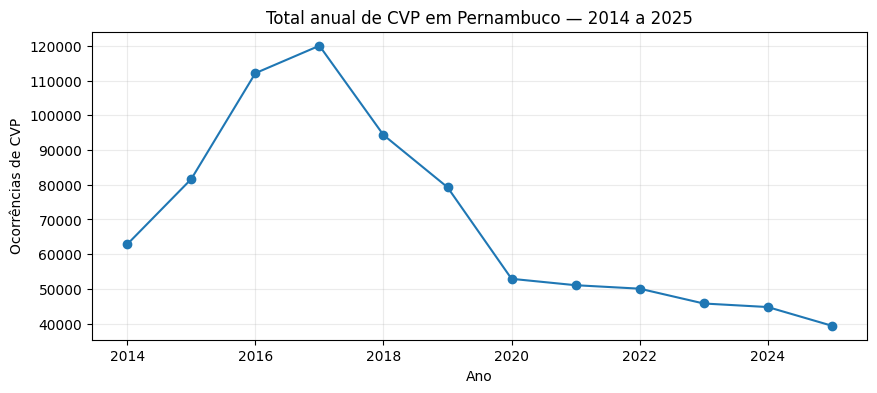

In [51]:
serie_anual = painel.groupby("ANO", as_index=False)["TOTAL_CVP"].sum()

display(serie_anual)

plt.figure(figsize=(10, 4))
plt.plot(serie_anual["ANO"], serie_anual["TOTAL_CVP"], marker="o")
plt.title("Total anual de CVP em Pernambuco — 2014 a 2025")
plt.xlabel("Ano")
plt.ylabel("Ocorrências de CVP")
plt.grid(alpha=0.25)
plt.show()

## 5. População e taxa de CVP

A comparação entre municípios utiliza a taxa mensal de CVP por 100 mil habitantes:

\[
\text{Taxa de CVP por 100 mil} =
\frac{\text{CVP}}{\text{População}} \times 100.000
\]

As informações populacionais são integradas a partir de fontes do IBGE. Para 2023, a população do Censo 2022 é mantida como referência e o respectivo ano de referência permanece registrado na base.

In [ ]:
import subprocess
import sys

resultado = subprocess.run(
    [sys.executable, str(PROJECT / "ETAPA_IBGE_POPULACAO_COLAB.py")],
    cwd=PROJECT,
    capture_output=True,
    text=True
)

if resultado.returncode != 0:
    print(resultado.stderr)
    raise RuntimeError("Falha na integração com os dados populacionais do IBGE.")

print("Integração populacional concluída.")

In [53]:
base_taxa = pd.read_csv(DATA / "base_municipio_mes_com_taxa.csv", sep=";")
perfil_cluster = pd.read_csv(DATA / "perfil_municipios_para_clustering.csv", sep=";")

print("Base município-mês com taxa:", base_taxa.shape)
print("Perfil municipal:", perfil_cluster.shape)
print("Total de CVP preservado:", int(base_taxa["TOTAL_CVP"].sum()))

display(base_taxa.head())
display(perfil_cluster.head())

Base município-mês com taxa: (26640, 11)
Perfil municipal: (185, 15)
Total de CVP preservado: 834398


,DATA_MES,ANO,MES,MUNICIPIO,REGIAO,COD_IBGE,TOTAL_CVP,POPULACAO_ANO,TAXA_CVP_100MIL_MES,ANO_REFERENCIA_POP,TIPO_POP
0,2014-01-01,2014,1,Abreu E Lima,Região Metropolitana,2600054,45,98201,45.824381,2014,Estimativa populacional
1,2014-02-01,2014,2,Abreu E Lima,Região Metropolitana,2600054,47,98201,47.861020,2014,Estimativa populacional
2,2014-03-01,2014,3,Abreu E Lima,Região Metropolitana,2600054,61,98201,62.117494,2014,Estimativa populacional
3,2014-04-01,2014,4,Abreu E Lima,Região Metropolitana,2600054,55,98201,56.007576,2014,Estimativa populacional
4,2014-05-01,2014,5,Abreu E Lima,Região Metropolitana,2600054,76,98201,77.392287,2014,Estimativa populacional


,MUNICIPIO,REGIAO,POPULACAO_2025,TOTAL_CVP_2014_2025,TAXA_MEDIA_MENSAL_100MIL,TAXA_MEDIANA_MENSAL_100MIL,DESVIO_PADRAO_TAXA,COEF_VARIACAO_TAXA,TENDENCIA_TAXA_POR_MES,AMPLITUDE_SAZONAL_TAXA,TAXA_ANUAL_2024_100MIL,TAXA_ANUAL_2025_100MIL,VARIACAO_TAXA_2025_VS_2024_PCT,MESES_ZERO,MAX_TAXA_MENSAL_100MIL
0,Abreu E Lima,Região Metropolitana,104248,9955,69.324099,56.704179,35.202015,0.507789,-0.545150,13.061061,495.454327,436.459213,-11.907276,0,167.062518
1,Afogados Da Ingazeira,Sertão,42672,381,6.933887,5.436654,5.421352,0.781863,-0.021428,4.503680,47.162025,82.020997,73.913221,19,24.997500
2,Afranio,Sertão,19409,107,3.840989,0.000000,5.446038,1.417874,-0.009929,5.146477,15.504677,46.370241,199.072602,80,30.838816
3,Agrestina,Agreste,24680,3334,94.300970,75.749978,51.051103,0.541364,-0.639298,20.350993,609.384522,575.364668,-5.582658,0,267.813667
4,Agua Preta,Zona Da Mata,26981,583,11.785025,10.878138,9.409488,0.798427,-0.076303,5.784619,51.430881,96.364108,87.366240,16,44.395117


## 6. Agrupamento dos municípios — K-Means

O agrupamento utiliza quatro características municipais:

- taxa média mensal por 100 mil habitantes;
- coeficiente de variação da taxa;
- tendência temporal;
- amplitude sazonal.

As variáveis são padronizadas antes do K-Means. Foram avaliadas soluções entre **K = 2** e **K = 8**, utilizando inércia, índice de silhueta e tamanho dos grupos como apoio à escolha.

In [ ]:
resultado = subprocess.run(
    [sys.executable, str(PROJECT / "ETAPA_CLUSTERING.py")],
    cwd=PROJECT,
    capture_output=True,
    text=True
)

if resultado.returncode != 0:
    print(resultado.stderr)
    raise RuntimeError("Falha na etapa de agrupamento.")

print("Agrupamento concluído.")

,K,INERCIA,SILHUETA_MEDIA,MENOR_CLUSTER,MAIOR_CLUSTER
0,2,415.316753,0.454948,55,130
1,3,313.730219,0.349204,35,103
2,4,245.372645,0.360860,20,90
3,5,199.375339,0.367515,1,90
4,6,164.326026,0.349952,1,79
5,7,142.730385,0.327089,1,65
6,8,121.391088,0.322037,1,64


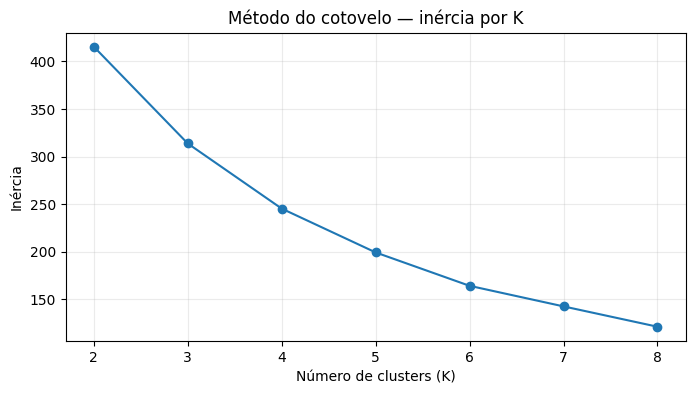

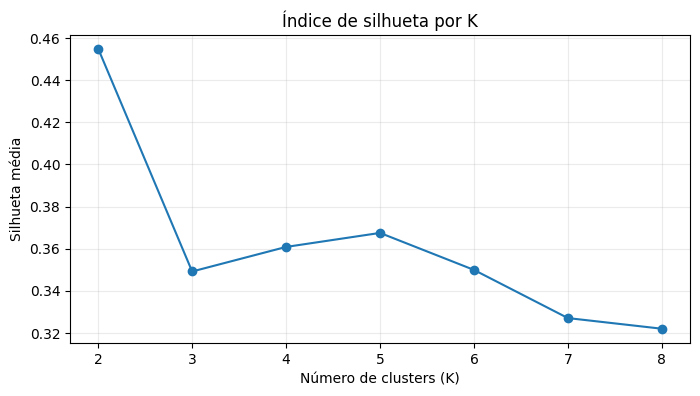

,CLUSTER,N_MUNICIPIOS,MEDIA_TAXA_MEDIA_MENSAL_100MIL,MEDIA_Z_TAXA_MEDIA_MENSAL_100MIL,MEDIA_COEF_VARIACAO_TAXA,MEDIA_Z_COEF_VARIACAO_TAXA,MEDIA_TENDENCIA_TAXA_POR_MES,MEDIA_Z_TENDENCIA_TAXA_POR_MES,MEDIA_AMPLITUDE_SAZONAL_TAXA,MEDIA_Z_AMPLITUDE_SAZONAL_TAXA
0,1,130,14.065305,-0.519345,1.142598,0.264205,-0.069424,0.498400,9.892041,-0.381373
1,2,55,56.196223,1.227544,0.609428,-0.624484,-0.402527,-1.178036,20.780136,0.901426


In [55]:
avaliacao_k = pd.read_csv(DATA / "avaliacao_k_clustering.csv", sep=";")
perfil_clusters = pd.read_csv(DATA / "perfil_clusters.csv", sep=";")
municipios_clusters = pd.read_csv(DATA / "municipios_clusters.csv", sep=";")

display(avaliacao_k)

plt.figure(figsize=(8, 4))
plt.plot(avaliacao_k["K"], avaliacao_k["INERCIA"], marker="o")
plt.title("Método do cotovelo — inércia por K")
plt.xlabel("Número de clusters (K)")
plt.ylabel("Inércia")
plt.grid(alpha=0.25)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(avaliacao_k["K"], avaliacao_k["SILHUETA_MEDIA"], marker="o")
plt.title("Índice de silhueta por K")
plt.xlabel("Número de clusters (K)")
plt.ylabel("Silhueta média")
plt.grid(alpha=0.25)
plt.show()

display(perfil_clusters)

### 6.1 Validação interna inicial

A comparação inicial entre **K = 2** e **K = 8** mostrou que K = 2 apresentou o maior índice de silhueta média (**0,4549**). Esse resultado é tratado como um diagnóstico de coesão e separação interna dos agrupamentos, e não como critério único para definir a solução substantivamente mais informativa.

Como uma solução com apenas dois grupos pode ocultar heterogeneidade relevante entre os municípios, são realizadas verificações adicionais de esparsidade e uma análise de sensibilidade para **K = 2, K = 3 e K = 4**.

,CLUSTER,N_MUNICIPIOS
0,1,130
1,2,55


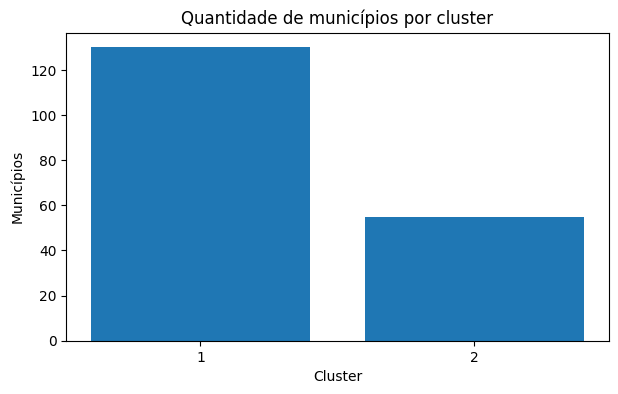

In [56]:
contagem_clusters = (
    municipios_clusters.groupby("CLUSTER")
    .size()
    .reset_index(name="N_MUNICIPIOS")
)

display(contagem_clusters)

plt.figure(figsize=(7, 4))
plt.bar(contagem_clusters["CLUSTER"].astype(str), contagem_clusters["N_MUNICIPIOS"])
plt.title("Quantidade de municípios por cluster")
plt.xlabel("Cluster")
plt.ylabel("Municípios")
plt.show()

### 6.2 Análise de esparsidade dos municípios

Como verificação adicional da robustez dos perfis municipais, examina-se a quantidade de informação disponível ao longo dos 144 meses do painel. São avaliados o total acumulado de CVP, a quantidade de meses com registro igual a zero e a proporção de meses com baixa contagem.

Os valores iguais a zero devem ser interpretados com cautela, pois o painel regular atribuiu zero às combinações município-mês ausentes na base original. Assim, esta análise caracteriza a **esparsidade observada no painel analítico**, sem assumir que toda ausência de registro corresponda necessariamente à inexistência de ocorrência criminal.

In [ ]:
# ============================================================
# ANÁLISE DE ESPARSIDADE DOS MUNICÍPIOS
# ============================================================

import pandas as pd
import numpy as np


# ------------------------------------------------------------
# 1. RESUMO MUNICIPAL A PARTIR DOS 144 MESES
# ------------------------------------------------------------

resumo_esparsidade = (
    base_taxa
    .groupby(
        ["MUNICIPIO", "REGIAO"],
        as_index=False
    )
    .agg(
        TOTAL_CVP_2014_2025=(
            "TOTAL_CVP",
            "sum"
        ),
        MEDIA_CVP_MENSAL=(
            "TOTAL_CVP",
            "mean"
        ),
        MEDIANA_CVP_MENSAL=(
            "TOTAL_CVP",
            "median"
        ),
        MAX_CVP_MENSAL=(
            "TOTAL_CVP",
            "max"
        ),
        MESES_ANALISADOS=(
            "TOTAL_CVP",
            "size"
        ),
        MESES_ZERO_PAINEL=(
            "TOTAL_CVP",
            lambda x: (x == 0).sum()
        ),
        MESES_COM_CVP=(
            "TOTAL_CVP",
            lambda x: (x > 0).sum()
        ),
        MESES_ATE_1_CVP=(
            "TOTAL_CVP",
            lambda x: (x <= 1).sum()
        )
    )
)


# ------------------------------------------------------------
# 2. PROPORÇÕES
# ------------------------------------------------------------

resumo_esparsidade[
    "PCT_MESES_ZERO"
] = (
    resumo_esparsidade[
        "MESES_ZERO_PAINEL"
    ]
    / resumo_esparsidade[
        "MESES_ANALISADOS"
    ]
    * 100
).round(2)

resumo_esparsidade[
    "PCT_MESES_ATE_1_CVP"
] = (
    resumo_esparsidade[
        "MESES_ATE_1_CVP"
    ]
    / resumo_esparsidade[
        "MESES_ANALISADOS"
    ]
    * 100
).round(2)

resumo_esparsidade[
    "MEDIA_CVP_MENSAL"
] = resumo_esparsidade[
    "MEDIA_CVP_MENSAL"
].round(2)

resumo_esparsidade[
    "MEDIANA_CVP_MENSAL"
] = resumo_esparsidade[
    "MEDIANA_CVP_MENSAL"
].round(2)


# ------------------------------------------------------------
# 3. ADICIONAR O CLUSTER ATUAL K=2
# ------------------------------------------------------------

if (
    "municipios_clusters" in globals()
    and "MUNICIPIO" in municipios_clusters.columns
    and "CLUSTER" in municipios_clusters.columns
):

    resumo_esparsidade = (
        resumo_esparsidade
        .merge(
            municipios_clusters[
                ["MUNICIPIO", "CLUSTER"]
            ],
            on="MUNICIPIO",
            how="left"
        )
    )


# ------------------------------------------------------------
# 4. RESUMO GERAL DOS 185 MUNICÍPIOS
# ------------------------------------------------------------

print(
    "===== DISTRIBUIÇÃO DA ESPARSIDADE ====="
)

estatisticas_esparsidade = (
    resumo_esparsidade[
        [
            "TOTAL_CVP_2014_2025",
            "MEDIA_CVP_MENSAL",
            "MEDIANA_CVP_MENSAL",
            "MESES_ZERO_PAINEL",
            "PCT_MESES_ZERO",
            "MESES_COM_CVP"
        ]
    ]
    .describe(
        percentiles=[
            0.10,
            0.25,
            0.50,
            0.75,
            0.90
        ]
    )
    .round(2)
)

display(
    estatisticas_esparsidade
)


# ------------------------------------------------------------
# 5. QUANTOS MUNICÍPIOS APRESENTAM MUITOS MESES ZERO
# ------------------------------------------------------------

faixas_zero = pd.DataFrame({
    "Critério": [
        "Pelo menos 25% dos meses com zero",
        "Pelo menos 50% dos meses com zero",
        "Pelo menos 75% dos meses com zero",
        "Mediana mensal igual a zero"
    ],
    "N_municípios": [
        (
            resumo_esparsidade[
                "PCT_MESES_ZERO"
            ] >= 25
        ).sum(),

        (
            resumo_esparsidade[
                "PCT_MESES_ZERO"
            ] >= 50
        ).sum(),

        (
            resumo_esparsidade[
                "PCT_MESES_ZERO"
            ] >= 75
        ).sum(),

        (
            resumo_esparsidade[
                "MEDIANA_CVP_MENSAL"
            ] == 0
        ).sum()
    ]
})

faixas_zero[
    "Percentual_dos_185"
] = (
    faixas_zero[
        "N_municípios"
    ]
    / 185
    * 100
).round(2)

print(
    "\n===== MUNICÍPIOS COM MAIOR ESPARSIDADE ====="
)

display(
    faixas_zero
)


# ------------------------------------------------------------
# 6. MUNICÍPIOS MAIS ESPARSOS
# ------------------------------------------------------------

mais_esparsos = (
    resumo_esparsidade
    .sort_values(
        [
            "PCT_MESES_ZERO",
            "TOTAL_CVP_2014_2025"
        ],
        ascending=[
            False,
            True
        ]
    )
    .head(20)
)

print(
    "\n===== 20 MUNICÍPIOS COM MAIS MESES ZERO ====="
)

colunas_exibir = [
    "MUNICIPIO",
    "REGIAO",
    "TOTAL_CVP_2014_2025",
    "MEDIA_CVP_MENSAL",
    "MEDIANA_CVP_MENSAL",
    "MESES_ZERO_PAINEL",
    "PCT_MESES_ZERO",
    "MESES_COM_CVP"
]

if "CLUSTER" in mais_esparsos.columns:
    colunas_exibir.append(
        "CLUSTER"
    )

display(
    mais_esparsos[
        colunas_exibir
    ]
)


# ------------------------------------------------------------
# 7. ESPARSIDADE POR CLUSTER ATUAL
# ------------------------------------------------------------

if "CLUSTER" in resumo_esparsidade.columns:

    esparsidade_cluster = (
        resumo_esparsidade
        .groupby(
            "CLUSTER"
        )
        .agg(
            N_MUNICIPIOS=(
                "MUNICIPIO",
                "count"
            ),
            MEDIANA_TOTAL_CVP=(
                "TOTAL_CVP_2014_2025",
                "median"
            ),
            MEDIA_PCT_MESES_ZERO=(
                "PCT_MESES_ZERO",
                "mean"
            ),
            MEDIANA_PCT_MESES_ZERO=(
                "PCT_MESES_ZERO",
                "median"
            ),
            MAX_PCT_MESES_ZERO=(
                "PCT_MESES_ZERO",
                "max"
            )
        )
        .round(2)
        .reset_index()
    )

    print(
        "\n===== ESPARSIDADE POR CLUSTER K=2 ====="
    )

    display(
        esparsidade_cluster
    )

### 6.3 Análise de sensibilidade da quantidade de clusters

Para verificar se a solução com dois grupos simplifica excessivamente a heterogeneidade municipal, são comparadas diretamente as soluções com **K = 2, K = 3 e K = 4**. A análise considera conjuntamente a silhueta média, a ocorrência de silhuetas individuais negativas, o tamanho dos grupos e a interpretação dos perfis formados.

A silhueta é utilizada nesta etapa como **critério interno de validação do agrupamento**, e não como medida de desempenho preditivo.

In [79]:
# ============================================================
# ANÁLISE DE SENSIBILIDADE — K = 2, K = 3 E K = 4
# ============================================================

import numpy as np
import pandas as pd

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    silhouette_score,
    silhouette_samples
)

variaveis_clustering = [
    "TAXA_MEDIA_MENSAL_100MIL",
    "COEF_VARIACAO_TAXA",
    "TENDENCIA_TAXA_POR_MES",
    "AMPLITUDE_SAZONAL_TAXA"
]

dados_sensibilidade = perfil_cluster[
    ["MUNICIPIO"] + variaveis_clustering
].copy()

print("Municípios analisados:", len(dados_sensibilidade))
print(
    "Valores ausentes:",
    dados_sensibilidade[variaveis_clustering].isna().sum().sum()
)

scaler_sensibilidade = StandardScaler()
X_sensibilidade = scaler_sensibilidade.fit_transform(
    dados_sensibilidade[variaveis_clustering]
)

resumo_k = []
perfis_k = []

for k in [2, 3, 4]:
    modelo_k = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=50
    )

    labels = modelo_k.fit_predict(X_sensibilidade)
    sil_media = silhouette_score(X_sensibilidade, labels)
    sil_individual = silhouette_samples(X_sensibilidade, labels)
    tamanhos = pd.Series(labels).value_counts()

    resumo_k.append({
        "K": k,
        "Inércia": modelo_k.inertia_,
        "Silhueta média": sil_media,
        "Menor cluster": tamanhos.min(),
        "Maior cluster": tamanhos.max(),
        "Municípios com silhueta negativa": (sil_individual < 0).sum(),
        "% silhueta negativa": (sil_individual < 0).mean() * 100
    })

    temp = dados_sensibilidade.copy()
    temp["CLUSTER_ORIGINAL"] = labels + 1

    temp = temp.merge(
        resumo_esparsidade[
            ["MUNICIPIO", "TOTAL_CVP_2014_2025", "PCT_MESES_ZERO"]
        ],
        on="MUNICIPIO",
        how="left"
    )

    perfil = (
        temp.groupby("CLUSTER_ORIGINAL")
        .agg(
            N_MUNICIPIOS=("MUNICIPIO", "count"),
            TAXA_MEDIA=("TAXA_MEDIA_MENSAL_100MIL", "mean"),
            COEF_VARIACAO=("COEF_VARIACAO_TAXA", "mean"),
            TENDENCIA=("TENDENCIA_TAXA_POR_MES", "mean"),
            AMPLITUDE_SAZONAL=("AMPLITUDE_SAZONAL_TAXA", "mean"),
            MEDIANA_TOTAL_CVP=("TOTAL_CVP_2014_2025", "median"),
            MEDIA_PCT_MESES_ZERO=("PCT_MESES_ZERO", "mean"),
            MEDIANA_PCT_MESES_ZERO=("PCT_MESES_ZERO", "median")
        )
        .reset_index()
        .sort_values("TAXA_MEDIA")
        .reset_index(drop=True)
    )

    perfil["PERFIL_ORDEM_INTENSIDADE"] = np.arange(1, len(perfil) + 1)
    perfil.insert(0, "K", k)
    perfis_k.append(perfil)

comparacao_k234 = pd.DataFrame(resumo_k).round({
    "Inércia": 2,
    "Silhueta média": 4,
    "% silhueta negativa": 2
})

print("\n===== COMPARAÇÃO K = 2, 3 E 4 =====")
display(comparacao_k234)

perfis_k234 = pd.concat(perfis_k, ignore_index=True)

colunas_numericas = [
    "TAXA_MEDIA",
    "COEF_VARIACAO",
    "TENDENCIA",
    "AMPLITUDE_SAZONAL",
    "MEDIANA_TOTAL_CVP",
    "MEDIA_PCT_MESES_ZERO",
    "MEDIANA_PCT_MESES_ZERO"
]

perfis_k234[colunas_numericas] = (
    perfis_k234[colunas_numericas].round(2)
)

print("\n===== PERFIS PARA K = 2, 3 E 4 =====")
display(
    perfis_k234[
        [
            "K",
            "PERFIL_ORDEM_INTENSIDADE",
            "CLUSTER_ORIGINAL",
            "N_MUNICIPIOS",
            "TAXA_MEDIA",
            "COEF_VARIACAO",
            "TENDENCIA",
            "AMPLITUDE_SAZONAL",
            "MEDIANA_TOTAL_CVP",
            "MEDIA_PCT_MESES_ZERO",
            "MEDIANA_PCT_MESES_ZERO"
        ]
    ]
)

Municípios analisados: 185
Valores ausentes: 0

===== COMPARAÇÃO K = 2, 3 E 4 =====


K,Inércia,Silhueta média,Menor cluster,Maior cluster,Municípios com silhueta negativa,% silhueta negativa
2,417.57,0.4549,55,130,2,1.08
3,315.44,0.3492,35,103,6,3.24
4,246.71,0.3609,20,90,4,2.16



===== PERFIS PARA K = 2, 3 E 4 =====


K,PERFIL_ORDEM_INTENSIDADE,CLUSTER_ORIGINAL,N_MUNICIPIOS,TAXA_MEDIA,COEF_VARIACAO,TENDENCIA,AMPLITUDE_SAZONAL,MEDIANA_TOTAL_CVP,MEDIA_PCT_MESES_ZERO,MEDIANA_PCT_MESES_ZERO
2,1,1,130,14.07,1.14,-0.07,9.89,367.5,28.15,17.02
2,2,2,55,56.20,0.61,-0.40,20.78,3334.0,1.24,0.00
3,1,1,47,4.99,1.72,-0.02,7.03,101.0,58.54,59.72
3,2,3,103,23.18,0.78,-0.12,12.87,662.0,9.30,6.94
3,3,2,35,65.65,0.58,-0.50,22.07,4483.0,0.54,0.00
4,1,3,22,3.64,2.21,-0.02,6.30,63.5,72.63,68.06
4,2,4,90,13.71,0.95,-0.06,9.39,394.5,21.40,13.89
4,3,1,53,38.62,0.69,-0.25,18.40,1412.0,3.79,0.69
4,4,2,20,77.91,0.56,-0.61,23.48,8512.5,0.17,0.00


### 6.4 Solução adotada após a análise de sensibilidade

Embora **K = 2** tenha apresentado a maior silhueta média (**0,4549**), a solução foi considerada demasiadamente agregada para a interpretação substantiva dos perfis municipais. A solução com **K = 4** apresentou silhueta média de **0,3609**, apenas quatro municípios com silhueta individual negativa e grupos com **22, 90, 53 e 20 municípios**, sem formação de grupos unitários.

Em K = 4, os perfis apresentaram uma progressão clara nas características analisadas. O Perfil 1 reúne municípios com baixa taxa média e elevada esparsidade do painel; o Perfil 2 apresenta intensidade ainda relativamente baixa, porém com maior frequência de registros; o Perfil 3 concentra valores intermediários a elevados de intensidade e sazonalidade; e o Perfil 4 reúne municípios com as maiores taxas médias, maior amplitude sazonal e praticamente ausência de meses com zero.

Por esse motivo, **K = 4 é adotado como solução principal para a interpretação dos perfis municipais**, enquanto K = 2 permanece como a solução de maior silhueta e é mantido como referência na análise de sensibilidade. Os perfis representam padrões estatísticos dos dados e não correspondem a classificações oficiais de segurança ou risco municipal.

In [80]:
# ============================================================
# SOLUÇÃO PRINCIPAL DE AGRUPAMENTO — K = 4
# ============================================================

modelo_k4_final = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=50
)

labels_k4 = modelo_k4_final.fit_predict(X_sensibilidade)

municipios_clusters_k4 = (
    perfil_cluster[
        [
            "MUNICIPIO",
            "REGIAO",
            "TAXA_MEDIA_MENSAL_100MIL",
            "COEF_VARIACAO_TAXA",
            "TENDENCIA_TAXA_POR_MES",
            "AMPLITUDE_SAZONAL_TAXA"
        ]
    ]
    .copy()
)

municipios_clusters_k4["CLUSTER_K4_RAW"] = labels_k4

ordem_k4 = (
    municipios_clusters_k4
    .groupby("CLUSTER_K4_RAW")["TAXA_MEDIA_MENSAL_100MIL"]
    .mean()
    .sort_values()
    .index
    .tolist()
)

mapa_perfis_k4 = {
    cluster_raw: posicao + 1
    for posicao, cluster_raw in enumerate(ordem_k4)
}

municipios_clusters_k4["PERFIL_K4"] = (
    municipios_clusters_k4["CLUSTER_K4_RAW"]
    .map(mapa_perfis_k4)
)

municipios_clusters_k4 = municipios_clusters_k4.merge(
    resumo_esparsidade[
        ["MUNICIPIO", "TOTAL_CVP_2014_2025", "PCT_MESES_ZERO"]
    ],
    on="MUNICIPIO",
    how="left"
)

perfil_clusters_k4 = (
    municipios_clusters_k4
    .groupby("PERFIL_K4")
    .agg(
        N_MUNICIPIOS=("MUNICIPIO", "count"),
        TAXA_MEDIA=("TAXA_MEDIA_MENSAL_100MIL", "mean"),
        COEF_VARIACAO=("COEF_VARIACAO_TAXA", "mean"),
        TENDENCIA=("TENDENCIA_TAXA_POR_MES", "mean"),
        AMPLITUDE_SAZONAL=("AMPLITUDE_SAZONAL_TAXA", "mean"),
        MEDIANA_TOTAL_CVP=("TOTAL_CVP_2014_2025", "median"),
        MEDIA_PCT_MESES_ZERO=("PCT_MESES_ZERO", "mean"),
        MEDIANA_PCT_MESES_ZERO=("PCT_MESES_ZERO", "median")
    )
    .reset_index()
    .round(2)
)

display(perfil_clusters_k4)

municipios_clusters_k4.to_csv(
    DATA / "municipios_clusters_k4.csv",
    sep=";",
    index=False,
    encoding="utf-8-sig"
)

perfil_clusters_k4.to_csv(
    DATA / "perfil_clusters_k4.csv",
    sep=";",
    index=False,
    encoding="utf-8-sig"
)

PERFIL_K4,N_MUNICIPIOS,TAXA_MEDIA,COEF_VARIACAO,TENDENCIA,AMPLITUDE_SAZONAL,MEDIANA_TOTAL_CVP,MEDIA_PCT_MESES_ZERO,MEDIANA_PCT_MESES_ZERO
1,22,3.64,2.21,-0.02,6.30,63.5,72.63,68.06
2,90,13.71,0.95,-0.06,9.39,394.5,21.40,13.89
3,53,38.62,0.69,-0.25,18.40,1412.0,3.79,0.69
4,20,77.91,0.56,-0.61,23.48,8512.5,0.17,0.00


### 6.5 Composição territorial dos quatro perfis

A composição territorial dos quatro perfis é examinada para verificar se os agrupamentos reproduzem simplesmente as regiões geográficas ou se apresentam estrutura própria. Para esta análise descritiva, **Fernando de Noronha é apresentado separadamente como Distrito Estadual**, sem alterar a variável `REGIAO` original proveniente da base nem a formação dos clusters.

Os resultados mostram associação territorial, porém os perfis não equivalem às regiões. O Perfil 1 apresenta forte concentração no Sertão, enquanto os Perfis 2 e 3 são territorialmente mais heterogêneos. O Perfil 4 reúne sobretudo municípios do Agreste e da Região Metropolitana, além do Recife.

Como análise complementar, é calculado o teste qui-quadrado de independência e o V de Cramér. Esses resultados são interpretados com cautela, pois algumas combinações perfil-região possuem frequências pequenas.

In [81]:
# ============================================================
# COMPOSIÇÃO TERRITORIAL DOS QUATRO PERFIS
# ============================================================

import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency


# ------------------------------------------------------------
# 1. BASE PARA ANÁLISE TERRITORIAL
# ------------------------------------------------------------

municipios_clusters_k4_territorio = municipios_clusters_k4.copy()

municipios_clusters_k4_territorio[
    "REGIAO_ANALISE"
] = municipios_clusters_k4_territorio[
    "REGIAO"
].copy()

# Fernando de Noronha é separado apenas na apresentação territorial.
# O valor original de REGIAO não é alterado e a correção não interfere
# na formação dos clusters.
mask_noronha = (
    municipios_clusters_k4_territorio[
        "MUNICIPIO"
    ]
    .astype(str)
    .str.upper()
    .eq("FERNANDO DE NORONHA")
)

municipios_clusters_k4_territorio.loc[
    mask_noronha,
    "REGIAO_ANALISE"
] = "Distrito Estadual"


# ------------------------------------------------------------
# 2. COMPOSIÇÃO REGIONAL POR PERFIL
# ------------------------------------------------------------

composicao_regional_k4 = (
    municipios_clusters_k4_territorio
    .groupby(
        ["PERFIL_K4", "REGIAO_ANALISE"]
    )
    .size()
    .reset_index(
        name="N_MUNICIPIOS"
    )
)

composicao_regional_k4[
    "PCT_DENTRO_PERFIL"
] = (
    composicao_regional_k4[
        "N_MUNICIPIOS"
    ]
    /
    composicao_regional_k4
    .groupby(
        "PERFIL_K4"
    )[
        "N_MUNICIPIOS"
    ]
    .transform("sum")
    * 100
).round(2)

print(
    "===== COMPOSIÇÃO TERRITORIAL DOS PERFIS K=4 ====="
)

display(
    composicao_regional_k4
)


# ------------------------------------------------------------
# 3. MATRIZ PERFIL × REGIÃO
# ------------------------------------------------------------

matriz_regional_k4 = pd.crosstab(
    municipios_clusters_k4_territorio[
        "PERFIL_K4"
    ],
    municipios_clusters_k4_territorio[
        "REGIAO_ANALISE"
    ],
    margins=True
)

print(
    "\n===== MATRIZ PERFIL × REGIÃO ====="
)

display(
    matriz_regional_k4
)


# ------------------------------------------------------------
# 4. ASSOCIAÇÃO ENTRE PERFIL E REGIÃO
# ------------------------------------------------------------

tabela_teste = pd.crosstab(
    municipios_clusters_k4_territorio[
        "PERFIL_K4"
    ],
    municipios_clusters_k4_territorio[
        "REGIAO_ANALISE"
    ]
)

chi2, p_valor, gl, esperadas = chi2_contingency(
    tabela_teste
)

n = tabela_teste.to_numpy().sum()

v_cramer = np.sqrt(
    chi2
    /
    (
        n
        * min(
            tabela_teste.shape[0] - 1,
            tabela_teste.shape[1] - 1
        )
    )
)

print(
    "\n===== ASSOCIAÇÃO PERFIL × REGIÃO ====="
)

print(
    f"Qui-quadrado: {chi2:.2f}"
)

print(
    f"Graus de liberdade: {gl}"
)

print(
    f"p-valor: {p_valor:.6g}"
)

print(
    f"V de Cramér: {v_cramer:.3f}"
)

print(
    "Observação: interpretar com cautela devido "
    "à existência de células com baixa frequência."
)

===== COMPOSIÇÃO TERRITORIAL DOS PERFIS K=4 =====


PERFIL_K4,REGIAO_ANALISE,N_MUNICIPIOS,PCT_DENTRO_PERFIL
1,Agreste,2,9.09
1,Distrito Estadual,1,4.55
1,Sertão,18,81.82
1,Zona Da Mata,1,4.55
2,Agreste,36,40.00
2,Região Metropolitana,1,1.11
2,Sertão,36,40.00
2,Zona Da Mata,17,18.89
3,Agreste,24,45.28
3,Região Metropolitana,5,9.43



===== MATRIZ PERFIL × REGIÃO =====


PERFIL_K4,Agreste,Distrito Estadual,Recife,Região Metropolitana,Sertão,Zona Da Mata,All
1,2,1,0,0,18,1,22
2,36,0,0,1,36,17,90
3,24,0,0,5,2,22,53
4,9,0,1,7,0,3,20
All,71,1,1,13,56,43,185



===== ASSOCIAÇÃO PERFIL × REGIÃO =====
Qui-quadrado: 102.97
Graus de liberdade: 15
p-valor: 3.55963e-15
V de Cramér: 0.431
Observação: interpretar com cautela devido à existência de células com baixa frequência.


## 7. Preparação da classificação temporal

Os atributos são construídos somente com informações disponíveis até o mês de referência. São utilizadas defasagens, médias móveis, medidas de variabilidade e tendência, frequência recente de meses sem ocorrência, sazonalidade e região.

O alvo possui cinco estados: **Muito Baixo, Baixo, Médio, Alto e Muito Alto**. Os limites são definidos a partir dos dados de treinamento, evitando o uso de informações do período de teste.

A estrutura temporal adotada é:

- **2014–2020:** treinamento interno;
- **2021–2022:** validação temporal;
- **2023–2025:** teste.

In [ ]:
resultado = subprocess.run(
    [sys.executable, str(PROJECT / "ETAPA_CLASSIFICACAO_DIAGNOSTICO.py")],
    cwd=PROJECT,
    capture_output=True,
    text=True
)

if resultado.returncode != 0:
    print(resultado.stderr)
    raise RuntimeError("Falha na preparação da base de classificação.")

print("Base de classificação preparada.")

In [58]:
base_class = pd.read_csv(DATA / "base_classificacao_preparada.csv", sep=";")

print("Amostras totais:", len(base_class))
print("\nPartições:")
display(base_class["PARTICAO"].value_counts().rename_axis("PARTICAO").reset_index(name="N"))

print("\nDistribuição das classes no teste:")
display(
    base_class.loc[base_class["PARTICAO"] == "TESTE", "ALVO_ESTADO_GLOBAL"]
    .value_counts()
    .rename_axis("CLASSE")
    .reset_index(name="N")
)

Amostras totais: 25530

Partições:


,PARTICAO,N
0,TREINO,18870
1,TESTE,6660



Distribuição das classes no teste:


,CLASSE,N
0,Muito Baixo,2134
1,Baixo,1715
2,Médio,1411
3,Alto,1092
4,Muito Alto,308


## 8. Modelos de classificação

A comparação utiliza modelos de famílias distintas, mantendo uma regra simples de persistência como referência:

- **Persistência:** estado do mês seguinte igual ao estado atual;
- **Regressão Logística Softmax:** referência linear multiclasse;
- **SVM com kernel RBF:** classificador não linear baseado em margens;
- **Random Forest:** ensemble baseado em árvores;
- **XGBoost:** boosting de árvores.

Os hiperparâmetros dos modelos não lineares são avaliados com a validação temporal de 2021–2022. Após a seleção da configuração, o modelo é reajustado com os dados até 2022 e avaliado em 2023–2025.

### 8.1 Pré-processamento comum

In [ ]:
import pandas as pd
import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

atributos_numericos = [
    "TAXA_ATUAL",
    "TAXA_LAG1",
    "TAXA_LAG2",
    "MEDIA_3M",
    "MEDIA_6M",
    "DP_3M",
    "DP_6M",
    "VARIACAO_1M",
    "VARIACAO_3M",
    "TENDENCIA_3M",
    "TENDENCIA_6M",
    "MESES_ZERO_ULT6",
    "MES_ALVO_SIN",
    "MES_ALVO_COS"
]

atributos_categoricos = ["REGIAO"]
atributos = atributos_numericos + atributos_categoricos
alvo = "ALVO_ESTADO_GLOBAL"

base_rf = base_class.copy()
base_rf["PARTICAO"] = base_rf["PARTICAO"].astype(str).str.upper().str.strip()

prep_numerico = Pipeline([
    ("imputacao", SimpleImputer(strategy="median"))
])

prep_categorico = Pipeline([
    ("imputacao", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessador = ColumnTransformer([
    ("num", prep_numerico, atributos_numericos),
    ("cat", prep_categorico, atributos_categoricos)
])

print("Treino:", (base_rf["PARTICAO"] == "TREINO").sum())
print("Teste:", (base_rf["PARTICAO"] == "TESTE").sum())

### 8.2 Persistência e Regressão Logística Softmax

In [63]:
import importlib.util
import contextlib
import io

modulo_path = PROJECT / "ETAPA_CLASSIFICACAO_MODELOS.py"

spec = importlib.util.spec_from_file_location(
    "adam_classificacao_aux",
    modulo_path
)
adam_aux = importlib.util.module_from_spec(spec)
spec.loader.exec_module(adam_aux)

rows = adam_aux.ler_csv(
    DATA / "base_classificacao_preparada.csv"
)

dados_soft = adam_aux.preparar_dados(rows)

X_train_soft = dados_soft["X_train"]
X_test_soft = dados_soft["X_test"]
y_train_soft = dados_soft["y_train"]
y_test_soft = dados_soft["y_test"]

# Persistência
pred_persist_train = adam_aux.prever_persistencia(
    dados_soft["train_rows"]
)
pred_persist_test = adam_aux.prever_persistencia(
    dados_soft["test_rows"]
)

metr_persist_train = adam_aux.metricas(
    y_train_soft,
    pred_persist_train
)
metr_persist_test = adam_aux.metricas(
    y_test_soft,
    pred_persist_test
)

persist_acc_train = metr_persist_train["accuracy"]
persist_f1_train = metr_persist_train["macro_f1"]

persist_acc_test = metr_persist_test["accuracy"]
persist_bal_test = metr_persist_test["balanced_accuracy"]
persist_f1_test = metr_persist_test["macro_f1"]

# Softmax sem balanceamento
with contextlib.redirect_stdout(io.StringIO()):
    softmax_final = adam_aux.SoftmaxRegression(
        balanced=False
    ).fit(
        X_train_soft,
        y_train_soft
    )

pred_soft_train = softmax_final.predict(X_train_soft)
pred_soft_test = softmax_final.predict(X_test_soft)

metr_soft_train = adam_aux.metricas(
    y_train_soft,
    pred_soft_train
)
metr_soft_test = adam_aux.metricas(
    y_test_soft,
    pred_soft_test
)

soft_acc_train = metr_soft_train["accuracy"]
soft_f1_train = metr_soft_train["macro_f1"]

soft_acc_test = metr_soft_test["accuracy"]
soft_bal_test = metr_soft_test["balanced_accuracy"]
soft_f1_test = metr_soft_test["macro_f1"]

print(
    "Persistência — teste: "
    f"Acc={persist_acc_test*100:.2f}% | "
    f"BalAcc={persist_bal_test*100:.2f}% | "
    f"F1 macro={persist_f1_test*100:.2f}%"
)

print(
    "Softmax — treino: "
    f"Acc={soft_acc_train*100:.2f}% | "
    f"F1 macro={soft_f1_train*100:.2f}%"
)

print(
    "Softmax — teste: "
    f"Acc={soft_acc_test*100:.2f}% | "
    f"BalAcc={soft_bal_test*100:.2f}% | "
    f"F1 macro={soft_f1_test*100:.2f}%"
)

Persistência — teste: Acc=48.74% | BalAcc=48.03% | F1 macro=47.96%
Softmax — treino: Acc=52.26% | F1 macro=51.82%
Softmax — teste: Acc=53.41% | BalAcc=50.15% | F1 macro=51.01%


### 8.3 Random Forest

In [63]:
# ============================================================
# RANDOM FOREST REGULARIZADO
# Ajuste usando validação temporal
# ============================================================

from sklearn.model_selection import ParameterGrid
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score
)

import pandas as pd


# ------------------------------------------------------------
# 1. DIVISÃO TEMPORAL INTERNA
# ------------------------------------------------------------

treino_interno = base_rf[
    (base_rf["PARTICAO"] == "TREINO") &
    (base_rf["ANO_ALVO"] <= 2020)
].copy()

validacao = base_rf[
    (base_rf["PARTICAO"] == "TREINO") &
    (base_rf["ANO_ALVO"] >= 2021) &
    (base_rf["ANO_ALVO"] <= 2022)
].copy()

print("Treinamento interno:", len(treino_interno))
print("Validação temporal:", len(validacao))


X_train_int = treino_interno[atributos]
y_train_int = treino_interno[alvo]

X_val = validacao[atributos]
y_val = validacao[alvo]


# ------------------------------------------------------------
# 2. CONFIGURAÇÕES A TESTAR
# ------------------------------------------------------------

grade = {
    "max_depth": [8, 12, 16],
    "min_samples_leaf": [5, 10, 20],
    "class_weight": [None, "balanced_subsample"]
}

resultados = []


# ------------------------------------------------------------
# 3. TESTAR AS CONFIGURAÇÕES
# ------------------------------------------------------------

for parametros in ParameterGrid(grade):

    modelo = Pipeline([
        ("preprocessamento", preprocessador),

        ("modelo", RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            n_jobs=-1,
            max_features="sqrt",
            max_depth=parametros["max_depth"],
            min_samples_leaf=parametros["min_samples_leaf"],
            min_samples_split=parametros["min_samples_leaf"] * 2,
            class_weight=parametros["class_weight"]
        ))
    ])

    modelo.fit(X_train_int, y_train_int)

    pred_train = modelo.predict(X_train_int)
    pred_val = modelo.predict(X_val)

    resultados.append({
        "MAX_DEPTH": parametros["max_depth"],
        "MIN_SAMPLES_LEAF": parametros["min_samples_leaf"],
        "CLASS_WEIGHT": str(parametros["class_weight"]),

        "ACURACIA_TREINO": accuracy_score(
            y_train_int, pred_train
        ),

        "F1_TREINO": f1_score(
            y_train_int,
            pred_train,
            average="macro"
        ),

        "ACURACIA_VALIDACAO": accuracy_score(
            y_val, pred_val
        ),

        "BAL_ACC_VALIDACAO": balanced_accuracy_score(
            y_val, pred_val
        ),

        "F1_VALIDACAO": f1_score(
            y_val,
            pred_val,
            average="macro"
        )
    })


resultado_grade = pd.DataFrame(resultados)

resultado_grade = resultado_grade.sort_values(
    ["F1_VALIDACAO", "BAL_ACC_VALIDACAO"],
    ascending=False
).reset_index(drop=True)


# mostrar em percentual
resultado_visual = resultado_grade.copy()

for coluna in [
    "ACURACIA_TREINO",
    "F1_TREINO",
    "ACURACIA_VALIDACAO",
    "BAL_ACC_VALIDACAO",
    "F1_VALIDACAO"
]:
    resultado_visual[coluna] = (
        resultado_visual[coluna] * 100
    ).round(2)


print("\nMELHORES CONFIGURAÇÕES")
display(resultado_visual.head(10))

Treinamento interno: 14430
Validação temporal: 4440

MELHORES CONFIGURAÇÕES


,MAX_DEPTH,MIN_SAMPLES_LEAF,CLASS_WEIGHT,ACURACIA_TREINO,F1_TREINO,ACURACIA_VALIDACAO,BAL_ACC_VALIDACAO,F1_VALIDACAO
0,8,10,None,59.19,58.25,52.07,52.68,52.75
1,8,5,None,59.79,58.83,51.89,52.57,52.61
2,8,20,None,58.24,57.23,51.87,52.44,52.50
3,8,20,balanced_subsample,58.32,57.49,52.23,51.72,52.25
4,8,10,balanced_subsample,59.33,58.53,52.16,51.70,52.25
5,8,5,balanced_subsample,59.84,59.04,52.05,51.65,52.17
6,12,20,None,63.56,62.77,51.44,51.96,51.98
7,16,20,None,64.57,63.80,51.40,51.78,51.85
8,12,5,None,74.54,73.97,50.99,51.44,51.65
9,12,20,balanced_subsample,63.62,62.98,51.31,51.14,51.58


In [65]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score

treino_final = base_rf[
    base_rf["PARTICAO"] == "TREINO"
].copy()

teste_final = base_rf[
    base_rf["PARTICAO"] == "TESTE"
].copy()

X_train = treino_final[atributos]
y_train = treino_final[alvo]

X_test = teste_final[atributos]
y_test = teste_final[alvo]

rf_final = Pipeline([
    ("preprocessamento", preprocessador),
    ("modelo", RandomForestClassifier(
        n_estimators=500,
        random_state=42,
        n_jobs=-1,
        max_features="sqrt",
        max_depth=8,
        min_samples_leaf=10,
        min_samples_split=20,
        class_weight=None
    ))
])

rf_final.fit(X_train, y_train)

pred_rf_train = rf_final.predict(X_train)
pred_rf_test = rf_final.predict(X_test)

rf_acc_train = accuracy_score(y_train, pred_rf_train)
rf_f1_train = f1_score(y_train, pred_rf_train, average="macro")

rf_acc_test = accuracy_score(y_test, pred_rf_test)
rf_bal_test = balanced_accuracy_score(y_test, pred_rf_test)
rf_f1_test = f1_score(y_test, pred_rf_test, average="macro")

print("Random Forest")
print(
    f"Treino: Acc={rf_acc_train*100:.2f}% | "
    f"F1 macro={rf_f1_train*100:.2f}%"
)
print(
    f"Teste: Acc={rf_acc_test*100:.2f}% | "
    f"BalAcc={rf_bal_test*100:.2f}% | "
    f"F1 macro={rf_f1_test*100:.2f}%"
)

Random Forest
Treino: Acc=57.75% | F1 macro=57.57%
Teste: Acc=55.15% | BalAcc=52.78% | F1 macro=53.75%


### 8.4 SVM-RBF

In [67]:
# ============================================================
# SVM-RBF - VALIDAÇÃO TEMPORAL
# Artigo ADAM
# ============================================================

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score
)

import pandas as pd


# ------------------------------------------------------------
# 1. PRÉ-PROCESSAMENTO ESPECÍFICO PARA SVM
# SVM precisa de padronização das variáveis numéricas
# ------------------------------------------------------------

prep_num_svm = Pipeline([
    ("imputacao", SimpleImputer(strategy="median")),
    ("padronizacao", StandardScaler())
])

prep_cat_svm = Pipeline([
    ("imputacao", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

preprocessador_svm = ColumnTransformer([
    ("num", prep_num_svm, atributos_numericos),
    ("cat", prep_cat_svm, atributos_categoricos)
])


# ------------------------------------------------------------
# 2. DIVISÃO TEMPORAL INTERNA
# 2014-2020 = treino
# 2021-2022 = validação
# ------------------------------------------------------------

treino_svm = base_rf[
    (base_rf["PARTICAO"] == "TREINO") &
    (base_rf["ANO_ALVO"] <= 2020)
].copy()

validacao_svm = base_rf[
    (base_rf["PARTICAO"] == "TREINO") &
    (base_rf["ANO_ALVO"] >= 2021) &
    (base_rf["ANO_ALVO"] <= 2022)
].copy()

X_train_svm = treino_svm[atributos]
y_train_svm = treino_svm[alvo]

X_val_svm = validacao_svm[atributos]
y_val_svm = validacao_svm[alvo]

print("Treinamento interno:", len(treino_svm))
print("Validação temporal:", len(validacao_svm))


# ------------------------------------------------------------
# 3. GRADE PEQUENA DE PARÂMETROS
# ------------------------------------------------------------

grade_svm = {
    "C": [1, 3],
    "gamma": ["scale", 0.1],
    "class_weight": [None, "balanced"]
}

resultados_svm = []


# ------------------------------------------------------------
# 4. TESTAR CONFIGURAÇÕES
# ------------------------------------------------------------

for parametros in ParameterGrid(grade_svm):

    modelo_svm = Pipeline([
        ("preprocessamento", preprocessador_svm),

        ("modelo", SVC(
            kernel="rbf",
            C=parametros["C"],
            gamma=parametros["gamma"],
            class_weight=parametros["class_weight"],
            cache_size=2000
        ))
    ])

    modelo_svm.fit(
        X_train_svm,
        y_train_svm
    )

    pred_train_svm = modelo_svm.predict(
        X_train_svm
    )

    pred_val_svm = modelo_svm.predict(
        X_val_svm
    )

    resultados_svm.append({

        "C":
            parametros["C"],

        "GAMMA":
            str(parametros["gamma"]),

        "CLASS_WEIGHT":
            str(parametros["class_weight"]),

        "ACURACIA_TREINO":
            accuracy_score(
                y_train_svm,
                pred_train_svm
            ),

        "F1_TREINO":
            f1_score(
                y_train_svm,
                pred_train_svm,
                average="macro"
            ),

        "ACURACIA_VALIDACAO":
            accuracy_score(
                y_val_svm,
                pred_val_svm
            ),

        "BAL_ACC_VALIDACAO":
            balanced_accuracy_score(
                y_val_svm,
                pred_val_svm
            ),

        "F1_VALIDACAO":
            f1_score(
                y_val_svm,
                pred_val_svm,
                average="macro"
            )
    })


# ------------------------------------------------------------
# 5. ORGANIZAR RESULTADOS
# ------------------------------------------------------------

resultado_svm = pd.DataFrame(
    resultados_svm
)

resultado_svm = resultado_svm.sort_values(
    [
        "F1_VALIDACAO",
        "BAL_ACC_VALIDACAO"
    ],
    ascending=False
).reset_index(drop=True)


resultado_svm_visual = resultado_svm.copy()

for coluna in [
    "ACURACIA_TREINO",
    "F1_TREINO",
    "ACURACIA_VALIDACAO",
    "BAL_ACC_VALIDACAO",
    "F1_VALIDACAO"
]:

    resultado_svm_visual[coluna] = (
        resultado_svm_visual[coluna] * 100
    ).round(2)


print("\nMELHORES CONFIGURAÇÕES - SVM RBF\n")

display(resultado_svm_visual)

Treinamento interno: 14430
Validação temporal: 4440

MELHORES CONFIGURAÇÕES - SVM RBF



,C,GAMMA,CLASS_WEIGHT,ACURACIA_TREINO,F1_TREINO,ACURACIA_VALIDACAO,BAL_ACC_VALIDACAO,F1_VALIDACAO
0,1,scale,None,54.86,53.79,51.10,51.74,51.98
1,1,0.1,None,55.97,54.92,50.99,51.63,51.85
2,1,0.1,balanced,56.01,55.13,51.42,51.11,51.84
3,3,scale,balanced,56.20,55.36,51.19,50.76,51.60
4,1,scale,balanced,54.93,53.98,51.35,50.89,51.59
5,3,0.1,None,58.25,57.25,50.65,51.08,51.39
6,3,scale,None,56.30,55.29,50.50,50.95,51.29
7,3,0.1,balanced,58.28,57.50,50.63,50.20,50.98


In [68]:
# ============================================================
# SVM-RBF FINAL
# Melhor configuração escolhida pela validação 2021-2022
# Teste final: 2023-2025
# ============================================================

from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score
)

# Dados finais
treino_final_svm = base_rf[
    base_rf["PARTICAO"] == "TREINO"
].copy()

teste_final_svm = base_rf[
    base_rf["PARTICAO"] == "TESTE"
].copy()

X_train_svm_final = treino_final_svm[atributos]
y_train_svm_final = treino_final_svm[alvo]

X_test_svm_final = teste_final_svm[atributos]
y_test_svm_final = teste_final_svm[alvo]


# Melhor configuração encontrada
svm_final = Pipeline([
    ("preprocessamento", preprocessador_svm),

    ("modelo", SVC(
        kernel="rbf",
        C=1,
        gamma="scale",
        class_weight=None,
        cache_size=2000
    ))
])

print("Treinando SVM-RBF final...")

svm_final.fit(
    X_train_svm_final,
    y_train_svm_final
)

print("Modelo treinado!")


# Previsões
pred_svm_train = svm_final.predict(
    X_train_svm_final
)

pred_svm_test = svm_final.predict(
    X_test_svm_final
)


# Métricas
svm_acc_train = accuracy_score(
    y_train_svm_final,
    pred_svm_train
)

svm_f1_train = f1_score(
    y_train_svm_final,
    pred_svm_train,
    average="macro"
)

svm_acc_test = accuracy_score(
    y_test_svm_final,
    pred_svm_test
)

svm_bal_test = balanced_accuracy_score(
    y_test_svm_final,
    pred_svm_test
)

svm_f1_test = f1_score(
    y_test_svm_final,
    pred_svm_test,
    average="macro"
)


print("\n========== SVM-RBF FINAL ==========")

print(f"Acurácia TREINO: {svm_acc_train*100:.2f}%")
print(f"F1 macro TREINO: {svm_f1_train*100:.2f}%")

print()

print(f"Acurácia TESTE: {svm_acc_test*100:.2f}%")
print(f"Balanced Accuracy TESTE: {svm_bal_test*100:.2f}%")
print(f"F1 macro TESTE: {svm_f1_test*100:.2f}%")

Treinando SVM-RBF final...
Modelo treinado!

========== SVM-RBF FINAL ==========
Acurácia TREINO: 54.65%
F1 macro TREINO: 54.41%

Acurácia TESTE: 54.74%
Balanced Accuracy TESTE: 51.78%
F1 macro TESTE: 52.89%


### 8.5 XGBoost

In [ ]:
!pip -q install xgboost

In [70]:
# ============================================================
# XGBOOST - VALIDAÇÃO TEMPORAL
# Artigo ADAM
# ============================================================

from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score
)

import pandas as pd


# ------------------------------------------------------------
# 1. DIVISÃO TEMPORAL
# 2014-2020 = treino interno
# 2021-2022 = validação
# ------------------------------------------------------------

treino_xgb = base_rf[
    (base_rf["PARTICAO"] == "TREINO") &
    (base_rf["ANO_ALVO"] <= 2020)
].copy()

validacao_xgb = base_rf[
    (base_rf["PARTICAO"] == "TREINO") &
    (base_rf["ANO_ALVO"] >= 2021) &
    (base_rf["ANO_ALVO"] <= 2022)
].copy()


X_train_xgb = treino_xgb[atributos]
X_val_xgb = validacao_xgb[atributos]


# ------------------------------------------------------------
# 2. CODIFICAR AS 5 CLASSES
# XGBoost trabalha melhor com classes numéricas
# ------------------------------------------------------------

le_xgb = LabelEncoder()

le_xgb.fit(base_rf[alvo])

y_train_xgb = le_xgb.transform(
    treino_xgb[alvo]
)

y_val_xgb = le_xgb.transform(
    validacao_xgb[alvo]
)


print("Treinamento interno:", len(treino_xgb))
print("Validação temporal:", len(validacao_xgb))

print("\nClasses:")
for numero, classe in enumerate(le_xgb.classes_):
    print(numero, "=", classe)


# ------------------------------------------------------------
# 3. GRADE PEQUENA
# ------------------------------------------------------------

grade_xgb = {
    "n_estimators": [200, 400],
    "learning_rate": [0.03, 0.05],
    "max_depth": [3, 5]
}

resultados_xgb = []


# ------------------------------------------------------------
# 4. TESTAR CONFIGURAÇÕES
# ------------------------------------------------------------

for parametros in ParameterGrid(grade_xgb):

    modelo_xgb = Pipeline([
        ("preprocessamento", preprocessador),

        ("modelo", XGBClassifier(
            n_estimators=parametros["n_estimators"],
            learning_rate=parametros["learning_rate"],
            max_depth=parametros["max_depth"],

            subsample=0.8,
            colsample_bytree=0.8,

            objective="multi:softprob",
            eval_metric="mlogloss",

            random_state=42,
            n_jobs=-1,
            tree_method="hist"
        ))
    ])

    modelo_xgb.fit(
        X_train_xgb,
        y_train_xgb
    )

    pred_train_xgb = modelo_xgb.predict(
        X_train_xgb
    )

    pred_val_xgb = modelo_xgb.predict(
        X_val_xgb
    )


    resultados_xgb.append({

        "N_ESTIMATORS":
            parametros["n_estimators"],

        "LEARNING_RATE":
            parametros["learning_rate"],

        "MAX_DEPTH":
            parametros["max_depth"],

        "ACURACIA_TREINO":
            accuracy_score(
                y_train_xgb,
                pred_train_xgb
            ),

        "F1_TREINO":
            f1_score(
                y_train_xgb,
                pred_train_xgb,
                average="macro"
            ),

        "ACURACIA_VALIDACAO":
            accuracy_score(
                y_val_xgb,
                pred_val_xgb
            ),

        "BAL_ACC_VALIDACAO":
            balanced_accuracy_score(
                y_val_xgb,
                pred_val_xgb
            ),

        "F1_VALIDACAO":
            f1_score(
                y_val_xgb,
                pred_val_xgb,
                average="macro"
            )
    })


# ------------------------------------------------------------
# 5. RESULTADOS
# ------------------------------------------------------------

resultado_xgb = pd.DataFrame(
    resultados_xgb
)

resultado_xgb = resultado_xgb.sort_values(
    [
        "F1_VALIDACAO",
        "BAL_ACC_VALIDACAO"
    ],
    ascending=False
).reset_index(drop=True)


resultado_xgb_visual = resultado_xgb.copy()

for coluna in [
    "ACURACIA_TREINO",
    "F1_TREINO",
    "ACURACIA_VALIDACAO",
    "BAL_ACC_VALIDACAO",
    "F1_VALIDACAO"
]:

    resultado_xgb_visual[coluna] = (
        resultado_xgb_visual[coluna] * 100
    ).round(2)


print("\nMELHORES CONFIGURAÇÕES - XGBOOST\n")

display(resultado_xgb_visual)

Treinamento interno: 14430
Validação temporal: 4440

Classes:
0 = Alto
1 = Baixo
2 = Muito Alto
3 = Muito Baixo
4 = Médio

MELHORES CONFIGURAÇÕES - XGBOOST



,N_ESTIMATORS,LEARNING_RATE,MAX_DEPTH,ACURACIA_TREINO,F1_TREINO,ACURACIA_VALIDACAO,BAL_ACC_VALIDACAO,F1_VALIDACAO
0,200,0.03,3,54.73,53.46,51.98,52.78,52.70
1,200,0.05,3,56.00,54.84,51.73,52.55,52.48
2,400,0.03,3,56.96,55.84,51.44,52.27,52.26
3,200,0.05,5,63.95,63.05,51.40,52.19,52.16
4,200,0.03,5,59.78,58.71,51.42,52.12,52.09
5,400,0.05,3,59.22,58.16,51.37,52.24,52.07
6,400,0.03,5,66.00,65.12,50.86,51.61,51.56
7,400,0.05,5,74.21,73.54,50.63,51.52,51.43


In [71]:
# ============================================================
# XGBOOST FINAL
# Melhor configuração escolhida na validação 2021-2022
# Teste final: 2023-2025
# ============================================================

from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score
)

# ------------------------------------------------------------
# 1. DADOS FINAIS
# ------------------------------------------------------------

treino_final_xgb = base_rf[
    base_rf["PARTICAO"] == "TREINO"
].copy()

teste_final_xgb = base_rf[
    base_rf["PARTICAO"] == "TESTE"
].copy()

X_train_xgb_final = treino_final_xgb[atributos]
X_test_xgb_final = teste_final_xgb[atributos]

y_train_xgb_final = le_xgb.transform(
    treino_final_xgb[alvo]
)

y_test_xgb_final = le_xgb.transform(
    teste_final_xgb[alvo]
)

print("Treino final:", len(treino_final_xgb))
print("Teste final:", len(teste_final_xgb))


# ------------------------------------------------------------
# 2. MELHOR CONFIGURAÇÃO
# ------------------------------------------------------------

xgb_final = Pipeline([
    ("preprocessamento", preprocessador),

    ("modelo", XGBClassifier(
        n_estimators=200,
        learning_rate=0.03,
        max_depth=3,

        subsample=0.8,
        colsample_bytree=0.8,

        objective="multi:softprob",
        eval_metric="mlogloss",

        random_state=42,
        n_jobs=-1,
        tree_method="hist"
    ))
])


print("\nTreinando XGBoost final...")

xgb_final.fit(
    X_train_xgb_final,
    y_train_xgb_final
)

print("Modelo treinado!")


# ------------------------------------------------------------
# 3. PREVISÕES
# ------------------------------------------------------------

pred_xgb_train = xgb_final.predict(
    X_train_xgb_final
)

pred_xgb_test = xgb_final.predict(
    X_test_xgb_final
)


# ------------------------------------------------------------
# 4. MÉTRICAS
# ------------------------------------------------------------

xgb_acc_train = accuracy_score(
    y_train_xgb_final,
    pred_xgb_train
)

xgb_f1_train = f1_score(
    y_train_xgb_final,
    pred_xgb_train,
    average="macro"
)

xgb_acc_test = accuracy_score(
    y_test_xgb_final,
    pred_xgb_test
)

xgb_bal_test = balanced_accuracy_score(
    y_test_xgb_final,
    pred_xgb_test
)

xgb_f1_test = f1_score(
    y_test_xgb_final,
    pred_xgb_test,
    average="macro"
)


print("\n========== XGBOOST FINAL ==========")

print(f"Acurácia TREINO: {xgb_acc_train*100:.2f}%")
print(f"F1 macro TREINO: {xgb_f1_train*100:.2f}%")

print()

print(f"Acurácia TESTE: {xgb_acc_test*100:.2f}%")
print(f"Balanced Accuracy TESTE: {xgb_bal_test*100:.2f}%")
print(f"F1 macro TESTE: {xgb_f1_test*100:.2f}%")

Treino final: 18870
Teste final: 6660

Treinando XGBoost final...
Modelo treinado!

========== XGBOOST FINAL ==========
Acurácia TREINO: 54.29%
F1 macro TREINO: 53.95%

Acurácia TESTE: 55.32%
Balanced Accuracy TESTE: 52.57%
F1 macro TESTE: 53.47%


### 8.6 Resultados da especificação A

Nesta etapa, todos os classificadores utilizam o mesmo conjunto de atributos históricos, sazonais e regionais. As métricas de treinamento são apresentadas junto às métricas de teste para permitir a verificação de diferenças de generalização.

In [ ]:
comparacao_treino = pd.DataFrame({
    "Modelo": [
        "Persistência",
        "Softmax",
        "SVM-RBF",
        "Random Forest",
        "XGBoost"
    ],
    "Acurácia treino (%)": [
        persist_acc_train * 100,
        soft_acc_train * 100,
        svm_acc_train * 100,
        rf_acc_train * 100,
        xgb_acc_train * 100
    ],
    "F1 macro treino (%)": [
        persist_f1_train * 100,
        soft_f1_train * 100,
        svm_f1_train * 100,
        rf_f1_train * 100,
        xgb_f1_train * 100
    ]
}).round(2)

comparacao_teste = pd.DataFrame({
    "Modelo": [
        "Persistência",
        "Softmax",
        "SVM-RBF",
        "Random Forest",
        "XGBoost"
    ],
    "Acurácia teste (%)": [
        persist_acc_test * 100,
        soft_acc_test * 100,
        svm_acc_test * 100,
        rf_acc_test * 100,
        xgb_acc_test * 100
    ],
    "Balanced Accuracy teste (%)": [
        persist_bal_test * 100,
        soft_bal_test * 100,
        svm_bal_test * 100,
        rf_bal_test * 100,
        xgb_bal_test * 100
    ],
    "F1 macro teste (%)": [
        persist_f1_test * 100,
        soft_f1_test * 100,
        svm_f1_test * 100,
        rf_f1_test * 100,
        xgb_f1_test * 100
    ]
}).round(2)

display(comparacao_treino)
display(comparacao_teste)

comparacao_treino.to_csv(
    "/content/comparacao_treino_especificacao_A.csv",
    sep=";",
    index=False
)

comparacao_teste.to_csv(
    "/content/comparacao_teste_especificacao_A.csv",
    sep=";",
    index=False
)

## 9. Contexto territorial e variáveis socioeconômicas

A especificação enriquecida acrescenta características estruturais e econômicas aos atributos históricos de CVP. O contexto territorial distingue **RMR**, **Interior** e **Distrito Estadual**. As variáveis quantitativas incorporadas são:

- PIB per capita municipal relativo à mediana de Pernambuco;
- densidade demográfica de 2010;
- taxa de urbanização de 2010.

O contexto territorial é utilizado principalmente na análise estratificada dos resultados, evitando duplicação direta com a variável regional já presente nos modelos.

In [ ]:
# ============================================================
# CONTEXTO TERRITORIAL
# RMR x INTERIOR x DISTRITO ESTADUAL
# ============================================================

municipios_rmr = [
    "Abreu E Lima",
    "Aracoiaba",
    "Cabo De Santo Agostinho",
    "Camaragibe",
    "Igarassu",
    "Itamaraca",
    "Ipojuca",
    "Itapissuma",
    "Jaboatao Dos Guararapes",
    "Moreno",
    "Olinda",
    "Paulista",
    "Recife",
    "Sao Lourenco Da Mata"
]

def classificar_territorio(municipio):
    if municipio == "Fernando De Noronha":
        return "Distrito Estadual"
    elif municipio in municipios_rmr:
        return "RMR"
    else:
        return "Interior"

base_class["CONTEXTO_TERRITORIAL"] = (
    base_class["MUNICIPIO"]
    .apply(classificar_territorio)
)

# Resumo
resumo_territorial = (
    base_class[
        ["MUNICIPIO", "CONTEXTO_TERRITORIAL"]
    ]
    .drop_duplicates()
    ["CONTEXTO_TERRITORIAL"]
    .value_counts()
    .rename_axis("GRUPO")
    .reset_index(name="MUNICIPIOS")
)

display(resumo_territorial)

### 9.1 PIB per capita

O PIB per capita é incorporado com defasagem de dois anos em relação ao ano-alvo. O valor municipal é dividido pela mediana dos municípios pernambucanos no mesmo ano e, posteriormente, transformado em logaritmo.

In [ ]:
import urllib.request
import zipfile
from pathlib import Path

url_pib = (
    "https://ftp.ibge.gov.br/Pib_Municipios/"
    "2022_2023/base/base_de_dados_2010_2023_xlsx.zip"
)

pasta_pib = Path("/content/pib_ibge")
pasta_pib.mkdir(exist_ok=True)
arquivo_zip = pasta_pib / "pib_2010_2023.zip"

if not arquivo_zip.exists():
    urllib.request.urlretrieve(url_pib, arquivo_zip)

with zipfile.ZipFile(arquivo_zip, "r") as z:
    z.extractall(pasta_pib)

arquivos = list(pasta_pib.glob("*.xlsx"))
if not arquivos:
    raise FileNotFoundError("Arquivo do PIB municipal não localizado.")

pib_br = pd.read_excel(arquivos[0])

print("Base PIB municipal:", len(pib_br), "linhas")
print("Período:", pib_br["Ano"].min(), "a", pib_br["Ano"].max())

In [ ]:
# ============================================================
# PIB IBGE - FILTRAR PERNAMBUCO E CONFERIR MUNICÍPIOS
# ============================================================

import unicodedata
import re
import pandas as pd


# ------------------------------------------------------------
# 1. FILTRAR SOMENTE PERNAMBUCO
# ------------------------------------------------------------

pib_pe = pib_br[
    pib_br["Sigla da Unidade da Federação"] == "PE"
].copy()

print("Linhas de Pernambuco:", len(pib_pe))
print(
    "Municípios/territórios distintos no arquivo:",
    pib_pe["Nome do Município"].nunique()
)

print(
    "Período disponível:",
    pib_pe["Ano"].min(),
    "a",
    pib_pe["Ano"].max()
)


# ------------------------------------------------------------
# 2. FUNÇÃO PARA PADRONIZAR NOMES
# ------------------------------------------------------------

def normalizar_nome(texto):

    texto = str(texto).strip()

    # remover acentos
    texto = unicodedata.normalize(
        "NFKD",
        texto
    ).encode(
        "ASCII",
        "ignore"
    ).decode(
        "ASCII"
    )

    # padronizar maiúsculas
    texto = texto.upper()

    # remover caracteres extras
    texto = re.sub(
        r"[^A-Z0-9 ]",
        " ",
        texto
    )

    texto = re.sub(
        r"\s+",
        " ",
        texto
    ).strip()

    return texto


pib_pe["MUNICIPIO_PADRAO"] = (
    pib_pe["Nome do Município"]
    .apply(normalizar_nome)
)

base_class["MUNICIPIO_PADRAO"] = (
    base_class["MUNICIPIO"]
    .apply(normalizar_nome)
)


# ------------------------------------------------------------
# 3. AJUSTES DE NOMES JÁ CONHECIDOS
# ------------------------------------------------------------

ajustes_nomes = {
    "BELEM DE SAO FRANCISCO":
        "BELEM DO SAO FRANCISCO",

    "ITAMARACA":
        "ILHA DE ITAMARACA",

    "SAO CAETANO":
        "SAO CAITANO",

    "IGUARACI":
        "IGUARACY",

    "LAGOA DO ITAENGA":
        "LAGOA DE ITAENGA"
}


base_class["MUNICIPIO_IBGE"] = (
    base_class["MUNICIPIO_PADRAO"]
    .replace(ajustes_nomes)
)


# ------------------------------------------------------------
# 4. COMPARAR AS DUAS BASES
# ------------------------------------------------------------

municipios_cvp = set(
    base_class["MUNICIPIO_IBGE"].unique()
)

municipios_pib = set(
    pib_pe["MUNICIPIO_PADRAO"].unique()
)

nao_encontrados = sorted(
    municipios_cvp - municipios_pib
)

extras_ibge = sorted(
    municipios_pib - municipios_cvp
)


print("\n================ CONFERÊNCIA ================\n")

print(
    "Municípios/territórios na base CVP:",
    len(municipios_cvp)
)

print(
    "Municípios encontrados na base PIB:",
    len(
        municipios_cvp.intersection(
            municipios_pib
        )
    )
)


print("\nNão encontrados no PIB:")
if nao_encontrados:
    for nome in nao_encontrados:
        print("-", nome)
else:
    print("✅ Todos encontrados!")


print("\nPresentes no PIB e não na base CVP:")
if extras_ibge:
    for nome in extras_ibge:
        print("-", nome)
else:
    print("Nenhum.")

In [ ]:
# ============================================================
# CRIAÇÃO DA VARIÁVEL PIB_PC_LAG2
# PIB per capita municipal com defasagem de 2 anos
# ============================================================

# ------------------------------------------------------------
# 1. IDENTIFICAR AUTOMATICAMENTE A COLUNA DE PIB PER CAPITA
# ------------------------------------------------------------

coluna_pib_pc = [
    c for c in pib_pe.columns
    if "Produto Interno Bruto per capita" in str(c)
][0]

print("Coluna identificada:")
print(coluna_pib_pc)


# ------------------------------------------------------------
# 2. PREPARAR BASE MUNICIPAL DO PIB
# ------------------------------------------------------------

pib_municipal = pib_pe[
    [
        "Ano",
        "MUNICIPIO_PADRAO",
        coluna_pib_pc
    ]
].copy()

pib_municipal = pib_municipal.rename(
    columns={
        "Ano": "ANO_PIB",
        coluna_pib_pc: "PIB_PC_LAG2"
    }
)

# garantir formato numérico
pib_municipal["ANO_PIB"] = pd.to_numeric(
    pib_municipal["ANO_PIB"],
    errors="coerce"
).astype("Int64")

pib_municipal["PIB_PC_LAG2"] = pd.to_numeric(
    pib_municipal["PIB_PC_LAG2"],
    errors="coerce"
)


# ------------------------------------------------------------
# 3. DEFINIR QUAL ANO DO PIB SERÁ USADO
# ------------------------------------------------------------

base_class["ANO_PIB"] = (
    base_class["ANO_ALVO"] - 2
)


# ------------------------------------------------------------
# 4. JUNTAR PIB À BASE DE CLASSIFICAÇÃO
# ------------------------------------------------------------

base_enriquecida = base_class.merge(
    pib_municipal,
    left_on=[
        "MUNICIPIO_IBGE",
        "ANO_PIB"
    ],
    right_on=[
        "MUNICIPIO_PADRAO",
        "ANO_PIB"
    ],
    how="left",
    suffixes=("", "_PIB")
)


# ------------------------------------------------------------
# 5. CONFERÊNCIA DA JUNÇÃO
# ------------------------------------------------------------

print("\n========== CONFERÊNCIA PIB PER CAPITA ==========\n")

print(
    "Linhas da base original:",
    len(base_class)
)

print(
    "Linhas após integração:",
    len(base_enriquecida)
)

print(
    "PIB per capita preenchido:",
    base_enriquecida["PIB_PC_LAG2"]
    .notna()
    .sum()
)

print(
    "PIB per capita ausente:",
    base_enriquecida["PIB_PC_LAG2"]
    .isna()
    .sum()
)

print(
    "\nPeríodo de PIB utilizado:",
    base_enriquecida["ANO_PIB"].min(),
    "a",
    base_enriquecida["ANO_PIB"].max()
)


if len(base_enriquecida) != len(base_class):
    raise RuntimeError("A junção do PIB alterou o número de linhas da base.")

if base_enriquecida["PIB_PC_LAG2"].isna().any():
    raise RuntimeError("Foram encontrados valores ausentes em PIB_PC_LAG2.")

In [ ]:
# ============================================================
# PIB PER CAPITA RELATIVO À MEDIANA DE PERNAMBUCO
# ============================================================

# Mediana do PIB per capita dos municípios de PE em cada ano
mediana_pib_ano = (
    pib_municipal
    .groupby("ANO_PIB")["PIB_PC_LAG2"]
    .median()
    .rename("MEDIANA_PIB_PE")
    .reset_index()
)

# Incorporar a mediana na base enriquecida
base_enriquecida = base_enriquecida.merge(
    mediana_pib_ano,
    on="ANO_PIB",
    how="left"
)

# Razão entre PIB per capita municipal e a mediana estadual
base_enriquecida["PIB_PC_REL_PE"] = (
    base_enriquecida["PIB_PC_LAG2"]
    / base_enriquecida["MEDIANA_PIB_PE"]
)

print("========== PIB RELATIVO ==========\n")

print(
    "Valores ausentes:",
    base_enriquecida["PIB_PC_REL_PE"].isna().sum()
)

print(
    "Mínimo:",
    round(base_enriquecida["PIB_PC_REL_PE"].min(), 3)
)

print(
    "Mediana:",
    round(base_enriquecida["PIB_PC_REL_PE"].median(), 3)
)

print(
    "Máximo:",
    round(base_enriquecida["PIB_PC_REL_PE"].max(), 3)
)

display(
    base_enriquecida[
        [
            "MUNICIPIO",
            "ANO_ALVO",
            "ANO_PIB",
            "PIB_PC_LAG2",
            "MEDIANA_PIB_PE",
            "PIB_PC_REL_PE"
        ]
    ]
    .drop_duplicates()
    .head(20)
)

In [ ]:
# ============================================================
# TRANSFORMAÇÃO DO PIB RELATIVO
# ============================================================

import numpy as np

base_enriquecida["LOG_PIB_PC_REL_PE"] = np.log(
    base_enriquecida["PIB_PC_REL_PE"]
)

print("========== LOG DO PIB RELATIVO ==========\n")

print(
    "Ausentes:",
    base_enriquecida["LOG_PIB_PC_REL_PE"].isna().sum()
)

print(
    "Mínimo:",
    round(base_enriquecida["LOG_PIB_PC_REL_PE"].min(), 3)
)

print(
    "Mediana:",
    round(base_enriquecida["LOG_PIB_PC_REL_PE"].median(), 3)
)

print(
    "Máximo:",
    round(base_enriquecida["LOG_PIB_PC_REL_PE"].max(), 3)
)

print("\nMaiores valores de PIB relativo:\n")

display(
    base_enriquecida[
        [
            "MUNICIPIO",
            "ANO_ALVO",
            "ANO_PIB",
            "PIB_PC_LAG2",
            "PIB_PC_REL_PE",
            "LOG_PIB_PC_REL_PE"
        ]
    ]
    .drop_duplicates()
    .sort_values(
        "PIB_PC_REL_PE",
        ascending=False
    )
    .head(10)
)

### 9.2 Densidade demográfica

A densidade demográfica de 2010 é utilizada como característica estrutural anterior ao período analisado. A transformação logarítmica reduz a assimetria entre municípios com densidades muito distintas.

In [ ]:
# ============================================================
# RECUPERAR DADOS DE DENSIDADE 2010 - IBGE
# ============================================================

import pandas as pd
import numpy as np
import requests
import unicodedata
import re


# ------------------------------------------------------------
# FUNÇÃO DE NORMALIZAÇÃO
# ------------------------------------------------------------

def normalizar_nome(texto):

    texto = str(texto).strip()

    texto = unicodedata.normalize(
        "NFKD",
        texto
    ).encode(
        "ASCII",
        "ignore"
    ).decode(
        "ASCII"
    )

    texto = texto.upper()

    texto = re.sub(
        r"[^A-Z0-9 ]",
        " ",
        texto
    )

    texto = re.sub(
        r"\s+",
        " ",
        texto
    ).strip()

    return texto


# ------------------------------------------------------------
# AJUSTES DE NOMES
# ------------------------------------------------------------

ajustes_nomes = {
    "BELEM DE SAO FRANCISCO":
        "BELEM DO SAO FRANCISCO",

    "ITAMARACA":
        "ILHA DE ITAMARACA",

    "SAO CAETANO":
        "SAO CAITANO",

    "IGUARACI":
        "IGUARACY",

    "LAGOA DO ITAENGA":
        "LAGOA DE ITAENGA"
}


# ------------------------------------------------------------
# BAIXAR DENSIDADE 2010
# ------------------------------------------------------------

url_densidade = (
    "https://apisidra.ibge.gov.br/values/"
    "t/1301/n6/all/v/616/p/2010?formato=json"
)

print("Baixando novamente a densidade 2010...")

resposta = requests.get(
    url_densidade,
    timeout=60
)

resposta.raise_for_status()

dados = resposta.json()

cabecalho = dados[0]

densidade_2010 = (
    pd.DataFrame(dados[1:])
    .rename(columns=cabecalho)
)


# ------------------------------------------------------------
# FILTRAR PERNAMBUCO
# ------------------------------------------------------------

col_municipio = "Município"
col_codigo = "Município (Código)"

densidade_pe = densidade_2010[
    densidade_2010[col_codigo]
    .astype(str)
    .str.startswith("26")
].copy()


# ------------------------------------------------------------
# CONVERTER DENSIDADE PARA NÚMERO
# ------------------------------------------------------------

def converter_numero(valor):

    texto = str(valor).strip()

    if "," in texto:
        texto = (
            texto
            .replace(".", "")
            .replace(",", ".")
        )

    return pd.to_numeric(
        texto,
        errors="coerce"
    )


densidade_pe["DENSIDADE_2010"] = (
    densidade_pe["Valor"]
    .apply(converter_numero)
)


# ------------------------------------------------------------
# CORRIGIR NOMES: REMOVER " - PE"
# ------------------------------------------------------------

densidade_pe["MUNICIPIO_LIMPO"] = (
    densidade_pe[col_municipio]
    .astype(str)
    .str.replace(
        r"\s*-\s*PE$",
        "",
        regex=True
    )
    .str.strip()
)

densidade_pe["MUNICIPIO_PADRAO"] = (
    densidade_pe["MUNICIPIO_LIMPO"]
    .apply(normalizar_nome)
)

densidade_pe["MUNICIPIO_IBGE"] = (
    densidade_pe["MUNICIPIO_PADRAO"]
    .replace(ajustes_nomes)
)


print("✅ densidade_pe reconstruída.")

print(
    "Territórios de PE:",
    densidade_pe["MUNICIPIO_IBGE"].nunique()
)

display(
    densidade_pe[
        [
            "Município",
            "MUNICIPIO_IBGE",
            "DENSIDADE_2010"
        ]
    ].head()
)

In [ ]:
# ============================================================
# INTEGRAR DENSIDADE DEMOGRÁFICA 2010
# ============================================================

# Uma linha por município
densidade_merge = (
    densidade_pe[
        ["MUNICIPIO_IBGE", "DENSIDADE_2010"]
    ]
    .drop_duplicates(subset="MUNICIPIO_IBGE")
    .copy()
)

print(
    "Municípios na tabela de densidade:",
    len(densidade_merge)
)


# ------------------------------------------------------------
# MERGE COM A BASE ENRIQUECIDA
# ------------------------------------------------------------

base_enriquecida = base_enriquecida.merge(
    densidade_merge,
    on="MUNICIPIO_IBGE",
    how="left",
    validate="many_to_one"
)


# ------------------------------------------------------------
# TRANSFORMAÇÃO LOGARÍTMICA
# ------------------------------------------------------------

base_enriquecida["LOG_DENSIDADE_2010"] = np.log(
    base_enriquecida["DENSIDADE_2010"]
)


# ------------------------------------------------------------
# CONFERÊNCIA
# ------------------------------------------------------------

print("\n========== DENSIDADE 2010 ==========\n")

print(
    "Linhas da base:",
    len(base_enriquecida)
)

print(
    "Densidade ausente:",
    base_enriquecida["DENSIDADE_2010"]
    .isna()
    .sum()
)

print(
    "Log densidade ausente:",
    base_enriquecida["LOG_DENSIDADE_2010"]
    .isna()
    .sum()
)

print(
    "\nDensidade mínima:",
    round(base_enriquecida["DENSIDADE_2010"].min(), 2)
)

print(
    "Densidade mediana:",
    round(base_enriquecida["DENSIDADE_2010"].median(), 2)
)

print(
    "Densidade máxima:",
    round(base_enriquecida["DENSIDADE_2010"].max(), 2)
)


if base_enriquecida["DENSIDADE_2010"].isna().any():
    raise RuntimeError("Foram encontrados valores ausentes em DENSIDADE_2010.")

### 9.3 Urbanização

A taxa de urbanização corresponde à proporção da população residente em área urbana no Censo 2010. A integração utiliza a tabela da Sinopse do Censo e valida a correspondência dos 185 territórios.

In [ ]:
import pandas as pd

url_urbanizacao = "https://censo2010.ibge.gov.br/sinopse/index.php?uf=26"

tabelas = pd.read_html(
    url_urbanizacao,
    decimal=",",
    thousands="."
)

tabela_urb = None

for tabela in tabelas:
    temp = tabela.copy()

    if isinstance(temp.columns, pd.MultiIndex):
        temp.columns = [
            " ".join(
                str(x) for x in col
                if str(x).lower() != "nan"
            ).strip()
            for col in temp.columns
        ]
    else:
        temp.columns = [str(c).strip() for c in temp.columns]

    if {"Município", "Total", "Urbana"}.issubset(set(temp.columns)):
        tabela_urb = temp
        break

if tabela_urb is None:
    raise RuntimeError("Tabela de urbanização do Censo 2010 não localizada.")

urbanizacao_pe = tabela_urb[
    ["Município", "Total", "Urbana"]
].copy()

urbanizacao_pe = urbanizacao_pe.rename(
    columns={
        "Município": "MUNICIPIO_ORIGINAL",
        "Total": "POP_TOTAL_2010",
        "Urbana": "POP_URBANA_2010"
    }
)

for coluna in ["POP_TOTAL_2010", "POP_URBANA_2010"]:
    urbanizacao_pe[coluna] = pd.to_numeric(
        urbanizacao_pe[coluna],
        errors="coerce"
    )

urbanizacao_pe["MUNICIPIO_LIMPO"] = (
    urbanizacao_pe["MUNICIPIO_ORIGINAL"]
    .astype(str)
    .str.replace(r"\s*-\s*PE$", "", regex=True)
    .str.strip()
)

urbanizacao_pe["MUNICIPIO_IBGE"] = (
    urbanizacao_pe["MUNICIPIO_LIMPO"]
    .apply(normalizar_nome)
    .replace(ajustes_nomes)
)

urbanizacao_pe = urbanizacao_pe[
    urbanizacao_pe["MUNICIPIO_IBGE"].isin(
        base_class["MUNICIPIO_IBGE"].unique()
    )
].copy()

urbanizacao_pe["URBANIZACAO_2010"] = (
    urbanizacao_pe["POP_URBANA_2010"]
    / urbanizacao_pe["POP_TOTAL_2010"]
    * 100
)

if urbanizacao_pe["MUNICIPIO_IBGE"].nunique() != 185:
    raise RuntimeError("A tabela de urbanização não corresponde aos 185 territórios.")

urbanizacao_merge = (
    urbanizacao_pe[
        ["MUNICIPIO_IBGE", "URBANIZACAO_2010"]
    ]
    .drop_duplicates(subset="MUNICIPIO_IBGE")
)

if "URBANIZACAO_2010" in base_enriquecida.columns:
    base_enriquecida = base_enriquecida.drop(
        columns=["URBANIZACAO_2010"]
    )

base_enriquecida = base_enriquecida.merge(
    urbanizacao_merge,
    on="MUNICIPIO_IBGE",
    how="left",
    validate="many_to_one"
)

if base_enriquecida["URBANIZACAO_2010"].isna().any():
    raise RuntimeError("Foram encontrados valores ausentes em URBANIZACAO_2010.")

print("Territórios:", urbanizacao_pe["MUNICIPIO_IBGE"].nunique())
print("Urbanização ausente:", base_enriquecida["URBANIZACAO_2010"].isna().sum())
print(
    "Intervalo:",
    round(base_enriquecida["URBANIZACAO_2010"].min(), 2),
    "a",
    round(base_enriquecida["URBANIZACAO_2010"].max(), 2)
)

## 10. Especificações A e B

A comparação final de atributos considera duas especificações:

**Especificação A:** histórico recente de CVP, sazonalidade e região.

**Especificação B:** especificação A acrescida de `LOG_PIB_PC_REL_PE`, `LOG_DENSIDADE_2010` e `URBANIZACAO_2010`.

A comparação entre A e B utiliza o período de **2021–2022** como validação temporal. O período de **2023–2025** permanece separado para a avaliação posterior da configuração selecionada.

In [ ]:
variaveis_numericas_A = [
    "TAXA_ATUAL",
    "TAXA_LAG1",
    "TAXA_LAG2",
    "MEDIA_3M",
    "MEDIA_6M",
    "DP_3M",
    "DP_6M",
    "VARIACAO_1M",
    "VARIACAO_3M",
    "TENDENCIA_3M",
    "TENDENCIA_6M",
    "MESES_ZERO_ULT6",
    "MES_ALVO_SIN",
    "MES_ALVO_COS"
]

variaveis_categoricas_A = ["REGIAO"]

variaveis_numericas_B = variaveis_numericas_A + [
    "LOG_PIB_PC_REL_PE",
    "LOG_DENSIDADE_2010",
    "URBANIZACAO_2010"
]

variaveis_categoricas_B = ["REGIAO"]

colunas_necessarias = (
    variaveis_numericas_B
    + variaveis_categoricas_B
    + ["ALVO_ESTADO_GLOBAL", "ANO_ALVO", "CONTEXTO_TERRITORIAL"]
)

faltantes = [
    c for c in colunas_necessarias
    if c not in base_enriquecida.columns
]

if faltantes:
    raise RuntimeError(f"Colunas ausentes na base enriquecida: {faltantes}")

treino_interno = base_enriquecida[
    base_enriquecida["ANO_ALVO"] <= 2020
].copy()

validacao_temporal = base_enriquecida[
    base_enriquecida["ANO_ALVO"].between(2021, 2022)
].copy()

teste_final = base_enriquecida[
    base_enriquecida["ANO_ALVO"].between(2023, 2025)
].copy()

print("Treino interno:", len(treino_interno))
print("Validação temporal:", len(validacao_temporal))
print("Teste final:", len(teste_final))
print(
    "Ausências nas entradas do Modelo B:",
    int(
        base_enriquecida[
            variaveis_numericas_B + variaveis_categoricas_B
        ].isna().sum().sum()
    )
)

## 11. Comparação entre as especificações A e B

A especificação A utiliza atributos históricos, sazonais e regionais. A especificação B acrescenta `LOG_PIB_PC_REL_PE`, `LOG_DENSIDADE_2010` e `URBANIZACAO_2010`.

A comparação é realizada exclusivamente na validação temporal de 2021–2022. O período de 2023–2025 permanece fora dessa etapa de seleção.

In [73]:
import pandas as pd
import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score
from xgboost import XGBClassifier

alvo_ab = "ALVO_ESTADO_GLOBAL"

y_treino_ab = treino_interno[alvo_ab]
y_validacao_ab = validacao_temporal[alvo_ab]

def criar_preprocessador(numericas, categoricas, padronizar=False):
    etapas_num = [
        ("imputacao", SimpleImputer(strategy="median"))
    ]

    if padronizar:
        etapas_num.append(
            ("padronizacao", StandardScaler())
        )

    prep_num = Pipeline(etapas_num)

    prep_cat = Pipeline([
        ("imputacao", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ])

    return ColumnTransformer([
        ("num", prep_num, numericas),
        ("cat", prep_cat, categoricas)
    ])

resultados_ab = []

especificacoes = {
    "A": {
        "numericas": variaveis_numericas_A,
        "categoricas": variaveis_categoricas_A
    },
    "B": {
        "numericas": variaveis_numericas_B,
        "categoricas": variaveis_categoricas_B
    }
}

for nome_esp, config in especificacoes.items():

    numericas = config["numericas"]
    categoricas = config["categoricas"]
    atributos_esp = numericas + categoricas

    X_train = treino_interno[atributos_esp]
    X_val = validacao_temporal[atributos_esp]

    # Regressão Logística Softmax
    prep_linear = criar_preprocessador(
        numericas,
        categoricas,
        padronizar=True
    )

    softmax = Pipeline([
        ("preprocessamento", prep_linear),
        (
            "modelo",
            LogisticRegression(
                max_iter=2000,
                solver="lbfgs"
            )
        )
    ])

    softmax.fit(X_train, y_treino_ab)
    pred = softmax.predict(X_val)

    resultados_ab.append({
        "Modelo": "Softmax",
        "Especificação": nome_esp,
        "Acurácia": accuracy_score(y_validacao_ab, pred),
        "Balanced Accuracy": balanced_accuracy_score(y_validacao_ab, pred),
        "F1 Macro": f1_score(y_validacao_ab, pred, average="macro")
    })

    # SVM-RBF
    prep_svm = criar_preprocessador(
        numericas,
        categoricas,
        padronizar=True
    )

    svm = Pipeline([
        ("preprocessamento", prep_svm),
        (
            "modelo",
            SVC(
                kernel="rbf",
                C=1,
                gamma="scale",
                class_weight=None,
                cache_size=2000
            )
        )
    ])

    svm.fit(X_train, y_treino_ab)
    pred = svm.predict(X_val)

    resultados_ab.append({
        "Modelo": "SVM-RBF",
        "Especificação": nome_esp,
        "Acurácia": accuracy_score(y_validacao_ab, pred),
        "Balanced Accuracy": balanced_accuracy_score(y_validacao_ab, pred),
        "F1 Macro": f1_score(y_validacao_ab, pred, average="macro")
    })

    # Random Forest
    prep_arvore = criar_preprocessador(
        numericas,
        categoricas,
        padronizar=False
    )

    rf = Pipeline([
        ("preprocessamento", prep_arvore),
        (
            "modelo",
            RandomForestClassifier(
                n_estimators=500,
                max_features="sqrt",
                max_depth=8,
                min_samples_leaf=10,
                min_samples_split=20,
                class_weight=None,
                random_state=42,
                n_jobs=-1
            )
        )
    ])

    rf.fit(X_train, y_treino_ab)
    pred = rf.predict(X_val)

    resultados_ab.append({
        "Modelo": "Random Forest",
        "Especificação": nome_esp,
        "Acurácia": accuracy_score(y_validacao_ab, pred),
        "Balanced Accuracy": balanced_accuracy_score(y_validacao_ab, pred),
        "F1 Macro": f1_score(y_validacao_ab, pred, average="macro")
    })

    # XGBoost
    encoder_alvo = LabelEncoder()
    y_train_xgb = encoder_alvo.fit_transform(y_treino_ab)
    y_val_xgb = encoder_alvo.transform(y_validacao_ab)

    xgb = Pipeline([
        ("preprocessamento", prep_arvore),
        (
            "modelo",
            XGBClassifier(
                n_estimators=200,
                learning_rate=0.03,
                max_depth=3,
                subsample=0.8,
                colsample_bytree=0.8,
                objective="multi:softprob",
                eval_metric="mlogloss",
                random_state=42,
                n_jobs=-1,
                tree_method="hist"
            )
        )
    ])

    xgb.fit(X_train, y_train_xgb)
    pred_xgb = xgb.predict(X_val)

    resultados_ab.append({
        "Modelo": "XGBoost",
        "Especificação": nome_esp,
        "Acurácia": accuracy_score(y_val_xgb, pred_xgb),
        "Balanced Accuracy": balanced_accuracy_score(y_val_xgb, pred_xgb),
        "F1 Macro": f1_score(y_val_xgb, pred_xgb, average="macro")
    })

comparacao_AB = pd.DataFrame(resultados_ab)

for coluna in ["Acurácia", "Balanced Accuracy", "F1 Macro"]:
    comparacao_AB[coluna] = (
        comparacao_AB[coluna] * 100
    ).round(2)

comparacao_AB = comparacao_AB.sort_values(
    ["Modelo", "Especificação"]
).reset_index(drop=True)

display(comparacao_AB)

tabela_A = (
    comparacao_AB[
        comparacao_AB["Especificação"] == "A"
    ]
    .set_index("Modelo")
)

tabela_B = (
    comparacao_AB[
        comparacao_AB["Especificação"] == "B"
    ]
    .set_index("Modelo")
)

ganho_AB = pd.DataFrame({
    "Δ Acurácia (B-A)": (
        tabela_B["Acurácia"] - tabela_A["Acurácia"]
    ),
    "Δ Balanced Accuracy (B-A)": (
        tabela_B["Balanced Accuracy"] - tabela_A["Balanced Accuracy"]
    ),
    "Δ F1 Macro (B-A)": (
        tabela_B["F1 Macro"] - tabela_A["F1 Macro"]
    )
}).round(2)

display(ganho_AB)

Modelo,Especificação,Acurácia,Balanced Accuracy,F1 Macro
Random Forest,A,52.16,52.71,52.82
Random Forest,B,52.68,53.39,53.40
SVM-RBF,A,51.10,51.74,51.98
SVM-RBF,B,51.26,52.09,52.09
Softmax,A,51.91,52.89,52.40
Softmax,B,51.46,52.59,52.14
XGBoost,A,51.98,52.78,52.70
XGBoost,B,51.44,52.54,52.32


Modelo,Δ Acurácia (B-A),Δ Balanced Accuracy (B-A),Δ F1 Macro (B-A)
Random Forest,0.52,0.68,0.58
SVM-RBF,0.16,0.35,0.11
Softmax,-0.45,-0.30,-0.26
XGBoost,-0.54,-0.24,-0.38


### 11.1 Resultado da validação temporal

A inclusão das variáveis contextuais produziu efeitos diferentes entre os classificadores. O maior ganho ocorreu no Random Forest, com aumento de **0,58 ponto percentual no F1 macro** e de **0,68 ponto percentual na balanced accuracy**. A especificação B do Random Forest apresentou o maior F1 macro da validação, **53,40%**, sendo selecionada para a avaliação temporal final.

No SVM-RBF, a alteração foi pequena. Softmax e XGBoost apresentaram leve redução do F1 macro com a especificação B. Assim, o efeito das variáveis contextuais não foi uniforme entre as famílias de modelos.

## 12. Random Forest — especificação B

Após a seleção na validação temporal, o Random Forest com a especificação B é reajustado com os alvos de 2014 a 2022 e avaliado em 2023–2025. A configuração de hiperparâmetros permanece a mesma selecionada anteriormente.

In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

atributos_num_B = [
    "TAXA_ATUAL",
    "TAXA_LAG1",
    "TAXA_LAG2",
    "MEDIA_3M",
    "MEDIA_6M",
    "DP_3M",
    "DP_6M",
    "VARIACAO_1M",
    "VARIACAO_3M",
    "TENDENCIA_3M",
    "TENDENCIA_6M",
    "MESES_ZERO_ULT6",
    "MES_ALVO_SIN",
    "MES_ALVO_COS",
    "LOG_PIB_PC_REL_PE",
    "LOG_DENSIDADE_2010",
    "URBANIZACAO_2010"
]

atributos_cat_B = ["REGIAO"]
atributos_B = atributos_num_B + atributos_cat_B
alvo_final = "ALVO_ESTADO_GLOBAL"

treino_final_B = base_enriquecida[
    base_enriquecida["ANO_ALVO"] <= 2022
].copy()

teste_final_B = base_enriquecida[
    base_enriquecida["ANO_ALVO"].between(2023, 2025)
].copy()

X_train_final_B = treino_final_B[atributos_B].copy()
y_train_final_B = treino_final_B[alvo_final].copy()

X_test_final_B = teste_final_B[atributos_B].copy()
y_test_final_B = teste_final_B[alvo_final].copy()

prep_num_B = Pipeline([
    ("imputacao", SimpleImputer(strategy="median"))
])

prep_cat_B = Pipeline([
    ("imputacao", SimpleImputer(strategy="most_frequent")),
    (
        "onehot",
        OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        )
    )
])

preprocessador_B = ColumnTransformer([
    ("num", prep_num_B, atributos_num_B),
    ("cat", prep_cat_B, atributos_cat_B)
])

rf_B_final = Pipeline([
    ("preprocessamento", preprocessador_B),
    (
        "modelo",
        RandomForestClassifier(
            n_estimators=500,
            max_features="sqrt",
            max_depth=8,
            min_samples_leaf=10,
            min_samples_split=20,
            class_weight=None,
            random_state=42,
            n_jobs=-1
        )
    )
])

rf_B_final.fit(
    X_train_final_B,
    y_train_final_B
)

pred_rf_B_train = rf_B_final.predict(
    X_train_final_B
)

pred_rf_B_test = rf_B_final.predict(
    X_test_final_B
)

rf_B_acc_train = accuracy_score(
    y_train_final_B,
    pred_rf_B_train
)

rf_B_bal_train = balanced_accuracy_score(
    y_train_final_B,
    pred_rf_B_train
)

rf_B_f1_train = f1_score(
    y_train_final_B,
    pred_rf_B_train,
    average="macro"
)

rf_B_acc_test = accuracy_score(
    y_test_final_B,
    pred_rf_B_test
)

rf_B_bal_test = balanced_accuracy_score(
    y_test_final_B,
    pred_rf_B_test
)

rf_B_f1_test = f1_score(
    y_test_final_B,
    pred_rf_B_test,
    average="macro"
)

print("Treino final:", len(treino_final_B))
print("Teste final:", len(teste_final_B))

print("\nTreino 2014-2022")
print(f"Acurácia: {rf_B_acc_train*100:.2f}%")
print(f"Balanced Accuracy: {rf_B_bal_train*100:.2f}%")
print(f"F1 Macro: {rf_B_f1_train*100:.2f}%")

print("\nTeste 2023-2025")
print(f"Acurácia: {rf_B_acc_test*100:.2f}%")
print(f"Balanced Accuracy: {rf_B_bal_test*100:.2f}%")
print(f"F1 Macro: {rf_B_f1_test*100:.2f}%")

ordem_classes = [
    "Muito Baixo",
    "Baixo",
    "Médio",
    "Alto",
    "Muito Alto"
]

relatorio_rf_B = classification_report(
    y_test_final_B,
    pred_rf_B_test,
    labels=ordem_classes,
    output_dict=True,
    zero_division=0
)

relatorio_rf_B_df = (
    pd.DataFrame(relatorio_rf_B)
    .T
    .round(4)
)

display(relatorio_rf_B_df)

matriz_rf_B = confusion_matrix(
    y_test_final_B,
    pred_rf_B_test,
    labels=ordem_classes
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=matriz_rf_B,
    display_labels=ordem_classes
)

fig, ax = plt.subplots(figsize=(8, 7))

disp.plot(
    ax=ax,
    values_format="d",
    cmap=None
)

plt.title(
    "Random Forest — Especificação B\n"
    "Matriz de confusão — 2023 a 2025"
)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

resultado_final_rf_B = (
    teste_final_B[
        [
            "MUNICIPIO",
            "ANO_ALVO",
            "MES_ALVO",
            "CONTEXTO_TERRITORIAL",
            alvo_final
        ]
    ]
    .copy()
)

resultado_final_rf_B["PREDITO"] = pred_rf_B_test

Treino final: 18870
Teste final: 6660

Treino 2014-2022
Acurácia: 58.24%
Balanced Accuracy: 58.23%
F1 Macro: 58.03%

Teste 2023-2025
Acurácia: 55.17%
Balanced Accuracy: 52.91%
F1 Macro: 53.67%


Classe,Precisão,Recall,F1-score,Suporte
Muito Baixo,0.6859,0.7202,0.7026,2134
Baixo,0.4636,0.4163,0.4387,1715
Médio,0.4307,0.4451,0.4378,1411
Alto,0.5475,0.5962,0.5708,1092
Muito Alto,0.6207,0.4675,0.5333,308


### 12.1 Desempenho no teste temporal

No período de 2023–2025, a especificação B apresentou **55,17% de acurácia**, **52,91% de balanced accuracy** e **53,67% de F1 macro**. O desempenho ficou próximo ao obtido anteriormente pelo Random Forest com a especificação A, que havia alcançado 55,15%, 52,78% e 53,75%, respectivamente.

A inclusão das variáveis contextuais, portanto, melhorou a validação 2021–2022, mas não produziu um ganho uniforme no período final. Houve pequeno aumento de acurácia e balanced accuracy e redução de 0,08 ponto percentual no F1 macro.

As classes `Muito Baixo` e `Alto` apresentaram os maiores F1 entre as cinco categorias no teste. `Baixo` e `Médio` concentraram os menores valores, evidenciando maior dificuldade de separação entre estados intermediários.

## 13. Análise territorial do modelo final

O desempenho do Random Forest B é examinado separadamente para a Região Metropolitana do Recife e para o Interior. Fernando de Noronha permanece como Distrito Estadual e não integra a comparação binária.

In [75]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report
)

resultados_territoriais = []

for grupo in ["RMR", "Interior"]:

    dados_grupo = resultado_final_rf_B[
        resultado_final_rf_B[
            "CONTEXTO_TERRITORIAL"
        ] == grupo
    ].copy()

    y_real = dados_grupo["ALVO_ESTADO_GLOBAL"]
    y_pred = dados_grupo["PREDITO"]

    resultados_territoriais.append({
        "Grupo": grupo,
        "Observações": len(dados_grupo),
        "Municípios": dados_grupo["MUNICIPIO"].nunique(),
        "Acurácia (%)": round(
            accuracy_score(y_real, y_pred) * 100,
            2
        ),
        "Balanced Accuracy (%)": round(
            balanced_accuracy_score(y_real, y_pred) * 100,
            2
        ),
        "F1 Macro (%)": round(
            f1_score(y_real, y_pred, average="macro") * 100,
            2
        )
    })

desempenho_territorial = pd.DataFrame(
    resultados_territoriais
)

display(desempenho_territorial)

ordem_classes = [
    "Muito Baixo",
    "Baixo",
    "Médio",
    "Alto",
    "Muito Alto"
]

resultados_classes_territorio = []

for grupo in ["RMR", "Interior"]:

    dados = resultado_final_rf_B[
        resultado_final_rf_B[
            "CONTEXTO_TERRITORIAL"
        ] == grupo
    ].copy()

    relatorio = classification_report(
        dados["ALVO_ESTADO_GLOBAL"],
        dados["PREDITO"],
        labels=ordem_classes,
        output_dict=True,
        zero_division=0
    )

    for classe in ordem_classes:
        resultados_classes_territorio.append({
            "Grupo": grupo,
            "Classe": classe,
            "Precisão (%)": round(
                relatorio[classe]["precision"] * 100,
                2
            ),
            "Recall (%)": round(
                relatorio[classe]["recall"] * 100,
                2
            ),
            "F1 (%)": round(
                relatorio[classe]["f1-score"] * 100,
                2
            ),
            "Suporte": int(
                relatorio[classe]["support"]
            )
        })

desempenho_classes_territorio = pd.DataFrame(
    resultados_classes_territorio
)

display(desempenho_classes_territorio)

Grupo,Observações,Municípios,Acurácia (%),Balanced Accuracy (%),F1 Macro (%)
RMR,504,14,65.67,51.53,53.44
Interior,6120,170,54.07,48.23,49.25


Grupo,Classe,Precisão (%),Recall (%),F1 (%),Suporte
RMR,Muito Baixo,37.50,30.00,33.33,10
RMR,Baixo,60.87,31.11,41.18,45
RMR,Médio,48.78,47.62,48.19,84
RMR,Alto,69.77,76.60,73.02,235
RMR,Muito Alto,70.68,72.31,71.48,130
Interior,Muito Baixo,68.27,71.77,69.98,2090
Interior,Baixo,46.14,41.92,43.93,1670
Interior,Médio,42.73,44.31,43.51,1327
Interior,Alto,50.59,55.09,52.74,855
Interior,Muito Alto,50.51,28.09,36.10,178


### 13.1 Diferenças territoriais

O F1 macro foi de **53,44% na RMR** e **49,25% no Interior**, diferença de 4,19 pontos percentuais. A balanced accuracy apresentou diferença menor, de 3,30 pontos percentuais.

A distribuição das classes é distinta entre os territórios. Na RMR, as classes `Alto` e `Muito Alto` concentraram grande parte das observações e apresentaram F1 de **73,02%** e **71,48%**. No Interior, o melhor desempenho ocorreu em `Muito Baixo`, com F1 de **69,98%**, enquanto `Muito Alto` apresentou F1 de **36,10%**.

Essas diferenças descrevem o comportamento do classificador nos dois contextos e não estabelecem relações causais entre território e risco.

## 14. Explicabilidade do modelo final — SHAP

A explicabilidade é aplicada somente ao Random Forest B. A importância global é calculada pela média dos valores SHAP absolutos em uma amostra de 2.000 observações do teste. Esse procedimento quantifica a contribuição das variáveis às previsões do modelo, sem interpretação causal.

Observações utilizadas no SHAP: 2000
Variáveis após pré-processamento: 22


Variável,Importância SHAP média
MEDIA_6M,0.044406
MEDIA_3M,0.034264
MESES_ZERO_ULT6,0.022202
TAXA_ATUAL,0.022195
TAXA_LAG1,0.016656
TAXA_LAG2,0.015003
LOG_DENSIDADE_2010,0.010302
URBANIZACAO_2010,0.006913
REGIAO_Sertão,0.006461
DP_6M,0.005612


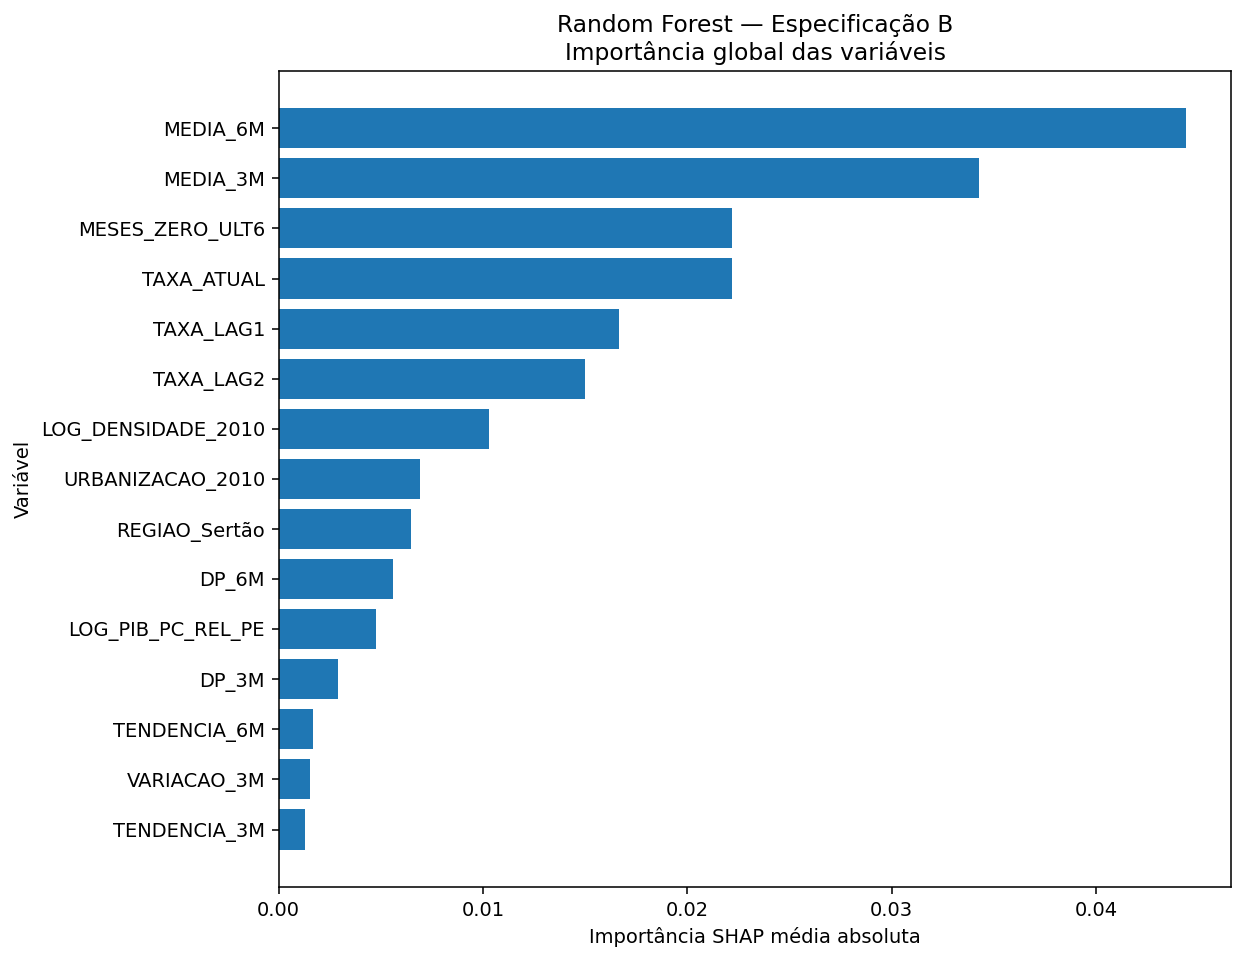

In [76]:
import sys
import subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import shap
except ImportError:
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "shap"],
        check=True
    )
    import shap

preprocessador_final = rf_B_final.named_steps[
    "preprocessamento"
]

modelo_final = rf_B_final.named_steps[
    "modelo"
]

nomes_features = (
    preprocessador_final
    .get_feature_names_out()
)

nomes_features = [
    nome.replace("num__", "")
        .replace("cat__", "")
    for nome in nomes_features
]

n_amostra = min(
    2000,
    len(X_test_final_B)
)

X_shap_original = X_test_final_B.sample(
    n=n_amostra,
    random_state=42
)

X_shap = preprocessador_final.transform(
    X_shap_original
)

X_shap_df = pd.DataFrame(
    X_shap,
    columns=nomes_features,
    index=X_shap_original.index
)

explainer = shap.TreeExplainer(
    modelo_final
)

shap_values = explainer.shap_values(
    X_shap_df
)

if isinstance(shap_values, list):

    matriz_importancia = np.mean(
        [
            np.abs(valor).mean(axis=0)
            for valor in shap_values
        ],
        axis=0
    )

else:

    shap_array = np.asarray(shap_values)

    if shap_array.ndim == 3:

        if shap_array.shape[1] == len(nomes_features):
            matriz_importancia = (
                np.abs(shap_array)
                .mean(axis=(0, 2))
            )

        elif shap_array.shape[2] == len(nomes_features):
            matriz_importancia = (
                np.abs(shap_array)
                .mean(axis=(0, 1))
            )

        else:
            raise RuntimeError(
                "Formato SHAP não reconhecido."
            )

    elif shap_array.ndim == 2:

        matriz_importancia = (
            np.abs(shap_array)
            .mean(axis=0)
        )

    else:
        raise RuntimeError(
            "Formato SHAP não reconhecido."
        )

importancia_shap = pd.DataFrame({
    "Variável": nomes_features,
    "Importância SHAP média": matriz_importancia
})

importancia_shap = (
    importancia_shap
    .sort_values(
        "Importância SHAP média",
        ascending=False
    )
    .reset_index(drop=True)
)

display(importancia_shap.head(20))

top15 = (
    importancia_shap
    .head(15)
    .sort_values(
        "Importância SHAP média"
    )
)

plt.figure(figsize=(9, 7))
plt.barh(
    top15["Variável"],
    top15["Importância SHAP média"]
)
plt.xlabel("Importância SHAP média absoluta")
plt.ylabel("Variável")
plt.title(
    "Random Forest — Especificação B\n"
    "Importância global das variáveis"
)
plt.tight_layout()
plt.show()

### 14.1 Importância global

As variáveis mais importantes são predominantemente temporais. `MEDIA_6M`, `MEDIA_3M`, `MESES_ZERO_ULT6`, `TAXA_ATUAL`, `TAXA_LAG1` e `TAXA_LAG2` ocupam as seis primeiras posições.

Entre as variáveis adicionadas na especificação B, `LOG_DENSIDADE_2010` aparece em 7º lugar, `URBANIZACAO_2010` em 8º e `LOG_PIB_PC_REL_PE` em 11º. As características estruturais acrescentam informação ao modelo, mas a dinâmica recente dos CVP permanece predominante.

In [77]:
classes_modelo = list(
    modelo_final.classes_
)

if isinstance(shap_values, list):

    shap_por_classe = np.stack(
        shap_values,
        axis=2
    )

else:

    shap_array = np.asarray(
        shap_values
    )

    if shap_array.ndim != 3:
        raise RuntimeError(
            "Formato SHAP multiclasse não reconhecido."
        )

    if shap_array.shape[1] == len(nomes_features):
        shap_por_classe = shap_array

    elif shap_array.shape[2] == len(nomes_features):
        shap_por_classe = np.transpose(
            shap_array,
            (0, 2, 1)
        )

    elif shap_array.shape[0] == len(classes_modelo):
        shap_por_classe = np.transpose(
            shap_array,
            (1, 2, 0)
        )

    else:
        raise RuntimeError(
            "Dimensões SHAP incompatíveis."
        )

resultados_shap_classe = []

for indice_classe, classe in enumerate(
    classes_modelo
):

    importancia = (
        np.abs(
            shap_por_classe[
                :,
                :,
                indice_classe
            ]
        )
        .mean(axis=0)
    )

    tabela = pd.DataFrame({
        "Classe": classe,
        "Variável": nomes_features,
        "Importância SHAP média": importancia
    })

    tabela = (
        tabela
        .sort_values(
            "Importância SHAP média",
            ascending=False
        )
        .reset_index(drop=True)
    )

    tabela["Posição"] = (
        np.arange(len(tabela)) + 1
    )

    resultados_shap_classe.append(
        tabela
    )

shap_classes_df = pd.concat(
    resultados_shap_classe,
    ignore_index=True
)

top8_classes = (
    shap_classes_df[
        shap_classes_df["Posição"] <= 8
    ]
    .copy()
)

top8_classes[
    "Importância SHAP média"
] = top8_classes[
    "Importância SHAP média"
].round(6)

display(
    top8_classes[
        [
            "Classe",
            "Posição",
            "Variável",
            "Importância SHAP média"
        ]
    ]
)

variaveis_contextuais = [
    "LOG_DENSIDADE_2010",
    "URBANIZACAO_2010",
    "LOG_PIB_PC_REL_PE"
]

contexto_shap_classes = (
    shap_classes_df[
        shap_classes_df[
            "Variável"
        ].isin(
            variaveis_contextuais
        )
    ]
    .copy()
)

contexto_shap_classes[
    "Importância SHAP média"
] = contexto_shap_classes[
    "Importância SHAP média"
].round(6)

contexto_shap_classes = (
    contexto_shap_classes
    .sort_values(
        ["Classe", "Posição"]
    )
)

display(
    contexto_shap_classes[
        [
            "Classe",
            "Variável",
            "Posição",
            "Importância SHAP média"
        ]
    ]
)

Formato: (2000, 22, 5)
Classes: ['Alto', 'Baixo', 'Muito Alto', 'Muito Baixo', 'Médio']


Classe,Variável,Posição,Importância SHAP média
Alto,LOG_DENSIDADE_2010,7,0.010864
Alto,URBANIZACAO_2010,8,0.006680
Alto,LOG_PIB_PC_REL_PE,11,0.002538
Baixo,URBANIZACAO_2010,7,0.008307
Baixo,LOG_DENSIDADE_2010,8,0.008076
Baixo,LOG_PIB_PC_REL_PE,11,0.004563
Muito Alto,URBANIZACAO_2010,7,0.006985
Muito Alto,LOG_DENSIDADE_2010,9,0.004821
Muito Alto,LOG_PIB_PC_REL_PE,11,0.003689
Muito Baixo,LOG_DENSIDADE_2010,7,0.017407


### 14.2 Variação por classe

`MEDIA_6M` ocupa a primeira posição de importância em todas as classes. A densidade demográfica aparece entre as variáveis contextuais mais relevantes em todas elas, alcançando a 5ª posição na classe `Médio`. A urbanização também se mantém entre as variáveis contextuais de maior contribuição. O PIB per capita relativo apresenta importância mais moderada.

Na classe `Muito Baixo`, `MESES_ZERO_ULT6` assume papel particularmente relevante, ocupando a 2ª posição. A variável `REGIAO_Sertão` também aparece entre as oito mais importantes nessa classe.

Os valores apresentados correspondem à magnitude média absoluta das contribuições SHAP. Eles indicam importância para as previsões, mas não determinam direção causal ou efeito isolado das variáveis.

## 15. Síntese dos resultados

Na etapa não supervisionada, K = 2 apresentou a maior silhueta média (**0,4549**), mas a análise de sensibilidade mostrou que essa solução agregava municípios com níveis muito diferentes de intensidade e esparsidade. Por esse motivo, **K = 4** foi adotado como solução principal para a interpretação dos perfis municipais. Os quatro grupos possuem **22, 90, 53 e 20 municípios** e apresentam diferenças graduais de intensidade média, variabilidade, tendência, sazonalidade e proporção de meses com zero. A silhueta média de K = 4 foi **0,3609**.

A análise de esparsidade mostrou que **35 dos 185 municípios (18,92%)** possuem pelo menos metade dos meses do painel com valor zero e que **9 municípios (4,86%)** possuem pelo menos 75% dos meses zerados. Essa característica é considerada na interpretação dos perfis e impede que baixa frequência de registros seja tratada automaticamente como baixa criminalidade.

A composição territorial mostrou que os quatro perfis apresentam associação com as regiões, mas não constituem mera reprodução da regionalização administrativa. O Perfil 1 concentra-se no Sertão, enquanto os Perfis 2 e 3 apresentam composição territorial mais diversificada. O Perfil 4 reúne principalmente municípios do Agreste e da Região Metropolitana, além do Recife. A associação perfil-região apresentou **V de Cramér de aproximadamente 0,43**, resultado interpretado apenas como evidência descritiva complementar devido à presença de células com baixa frequência.

Na classificação, a comparação temporal entre as especificações A e B mostrou que as variáveis contextuais beneficiaram principalmente o Random Forest na validação de 2021–2022. O Random Forest B alcançou **53,40% de F1 macro** nessa etapa e foi selecionado antes da avaliação final.

No teste de 2023–2025, o modelo selecionado apresentou **55,17% de acurácia**, **52,91% de balanced accuracy** e **53,67% de F1 macro**. O desempenho foi superior ao baseline de persistência, embora a especificação B tenha permanecido muito próxima da especificação A no teste final.

A análise territorial da classificação mostrou F1 macro de **53,44% na RMR** e **49,25% no Interior**, com diferenças importantes entre as classes. O SHAP indicou que a classificação é explicada principalmente pela dinâmica recente dos CVP. Densidade demográfica, urbanização e PIB per capita relativo também contribuíram para as previsões, em magnitude menor que as variáveis históricas.

## 16. Arquivos de resultados

As principais tabelas da etapa final são exportadas em formato CSV para facilitar a incorporação dos resultados ao artigo.

In [78]:
from pathlib import Path

saida_final = Path(
    "/content/resultados_finais_ADAM"
)

saida_final.mkdir(
    parents=True,
    exist_ok=True
)

comparacao_AB.to_csv(
    saida_final / "comparacao_especificacoes_A_B.csv",
    sep=";",
    index=False
)

ganho_AB.reset_index().to_csv(
    saida_final / "ganho_especificacao_B.csv",
    sep=";",
    index=False
)

relatorio_rf_B_df.to_csv(
    saida_final / "metricas_por_classe_RF_B.csv",
    sep=";"
)

desempenho_territorial.to_csv(
    saida_final / "desempenho_territorial_RF_B.csv",
    sep=";",
    index=False
)

desempenho_classes_territorio.to_csv(
    saida_final / "desempenho_por_classe_territorio_RF_B.csv",
    sep=";",
    index=False
)

importancia_shap.to_csv(
    saida_final / "importancia_SHAP_RF_B.csv",
    sep=";",
    index=False
)

contexto_shap_classes.to_csv(
    saida_final / "SHAP_contextuais_por_classe_RF_B.csv",
    sep=";",
    index=False
)

print(saida_final)

/content/resultados_finais_ADAM
